In [45]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, curve_fit
from scipy.interpolate import interp1d, CubicSpline
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation
from tqdm import tqdm
import glob, os, warnings, time, datetime, pickle
from collections import defaultdict
np.set_printoptions(threshold=np.inf, precision=10)

In [107]:
# Read the GHI Input Data, derived from NASA ACCESS
solar_df = pd.read_csv(r"./data/GHI Data USGS Site.csv", header=9, engine='python', skipfooter=0)
solar_df['datetime'] = pd.to_datetime(solar_df[['YEAR', 'MO', 'DY', 'HR']].astype(str).agg('-'.join, axis=1), format='%Y-%m-%d-%H')
solar_df['MO'] = solar_df['datetime'].dt.month
solar_df['DY'] = solar_df['datetime'].dt.day
solar_df['HR'] = solar_df['datetime'].dt.hour
historical_avg = (solar_df.groupby(['MO', 'DY', 'HR'])['ALLSKY_SFC_SW_DWN'].transform('mean'))
solar_df['Average'] = historical_avg

In [108]:
# Read the Streamlevels input data, derived from USGS
threat_data_raw = pd.read_csv(r"./data/processed_mississippi_data_interpolated_2021_2022.csv")
threat_data_raw = threat_data_raw.interpolate(method='polynomial', order=5)
threat_data_raw["Unit"] = pd.to_datetime(threat_data_raw["Unit"])

C:\Users\nihal\AppData\Local\Temp\ipykernel_9932\3951734694.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  threat_data_raw = threat_data_raw.interpolate(method='polynomial', order=5)


The RBF Kernel is used to model a Gaussian Process

In [67]:
def kernel(x1, x2, t=1.0, sigma=1):
    sqdist = np.subtract.outer(x1, x2)**2
    return sigma**2 * np.exp(-0.5*sqdist / (t**2))

Induce the Martingale Model of Forecast Evolution (MMFE)

In [68]:
def growth_martingale(t, alpha=0.1):
    """
    MMFE property: Variance grows linearly with lead time.
    Standard Deviation (scaling factor) grows with sqrt(t).
    """
    return alpha * np.sqrt(t + 1e-6)

-------------------------------------------------------------------------------------

HELPER FUNCTIONS IMPLEMENTING THE ENSEMBLE KALMAN FILTER

-------------------------------------------------------------------------------------

In [69]:
def get_observational_data(threat_data_raw, inter_transmission_time):
    df = threat_data_raw.copy()
    df['Unit'] = pd.to_datetime(df['Unit'])
    df = df.set_index('Unit')
    resampled_parts = []
    start = df.index.min()
    for dt_min in tqdm(inter_transmission_time):
        end = start + pd.Timedelta(hours=1)
        df_hour = df.loc[start:end]
        if df_hour.empty:
            print(f"Empty: {df_hour}")
            print(f"End Time: {end}")
        if not df_hour.empty:
            dt_sec = int(round(dt_min * 60))
            df_r = (
                df_hour
                .resample(f'{dt_sec}s', origin=start, closed='left', label='left')
                .mean()
                .interpolate(method='time')
            )
            resampled_parts.append(df_r)
            # mask = (df_r.index >= start) & (df_r.index < end)
            # resampled_parts.append(df_r[mask])
        start = end
    threat_resampled = pd.concat(resampled_parts, ignore_index=False)
    threat_resampled.index = threat_resampled.index.tz_localize(None)
    return threat_resampled

In [70]:
def generate_confidence_fans(observed_df, sigma, bias, n_samples=1000, horizon_hours=4, step_hours=1, t=1, alpha=0.2, seed=None):
    """
    Generate ensemble trajectories over a fixed forecasting horizon
    using observation timestamps, suitable for EnKF updates.
    Forecast uncertainty increases linearly with time
    """
    # fontsize=19
    # linewidth=3
    # plt.figure(figsize=(14, 5))
    # plt.style.use('seaborn-v0_8')
    # _, ax1 = plt.subplots(figsize=(12.5,5))
    # observed_df = observed_df.tz_localize(None)
    observed_df = observed_df.tz_localize(None)

    records = []
    times = observed_df.index
    signal = observed_df["Instantaneous Stream Level (ft)"].to_numpy()

    start_time = times[0]
    end_time = times[-1]
    step = pd.Timedelta(hours=step_hours)
    horizon = pd.Timedelta(hours=horizon_hours)

    window_id = 0
    t0 = start_time
    # ax1.plot(times, signal, color='black', linewidth=linewidth, label='Observations', zorder=10)
    # first_ensemble=True
    pbar = tqdm(total=int((end_time - start_time) / step) + 1)
    while t0 <= end_time:
        t_end = t0 + horizon
        mask = (times >= t0) & (times <= t_end)
        ts_window = times[mask]

        if len(ts_window) < 2:
            t0 += step
            continue

        current_signal = signal[mask]

        # relative times in hours
        rel_t = (ts_window - ts_window[0]).total_seconds() / 3600
        n_steps = len(rel_t)
        # rng = np.random.default_rng(window_id)
        rng = np.random.default_rng(seed)
        base_cov = kernel(rel_t, rel_t, t=t, sigma=sigma)
        g = growth_martingale(rel_t, alpha=alpha)
        cov_matrix = base_cov * np.outer(g, g)
                
        bias_mean = bias[0]
        bias_std = bias[1]
        member_biases = rng.normal(loc=bias_mean, scale=bias_std, size=n_samples)
        noise = rng.multivariate_normal(np.zeros(n_steps), cov_matrix, size=n_samples)
        ensembles = current_signal + noise + member_biases[:, np.newaxis]

        # window_start_time = ts_window[0]
        # if window_start_time.hour % horizon_hours == 0:
        #     lower = np.percentile(ensembles, 2.5, axis=0)
        #     upper = np.percentile(ensembles, 97.5, axis=0)
        #     ax1.fill_between(ts_window, lower, upper, alpha=0.3)
        #     lbl = "Ensemble Realization" if first_ensemble else None
        #     ax1.plot(ts_window, ensembles[-1], color='teal', alpha=0.5, label=lbl)
        #     first_ensemble = False

        window_values = ensembles.ravel()
        window_times = np.tile(ts_window, n_samples)
        ensemble_ids = np.repeat(np.arange(n_samples), n_steps)
        step_ids = np.tile(np.arange(n_steps), n_samples)
        window_df = pd.DataFrame({
            "window_id": window_id,
            "ensemble_id": ensemble_ids,
            "step": step_ids,
            "timestamp": window_times,
            "value": window_values
        })
        records.append(window_df)

        # for e in range(n_samples):
        #     for k, ts in enumerate(ts_window):
        #         records.append({
        #             "window_id": window_id,
        #             "ensemble_id": e,
        #             "step": k,
        #             "timestamp": ts,
        #             "value": ensembles[e, k]
        #         })
        window_id += 1
        t0 += step
        pbar.update(1)
    pbar.close()
    # df_long = pd.DataFrame(records)
    df_long = pd.concat(records, ignore_index=True)
    # ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
    # for ax in [ax1]:
    #     for spine in ax.spines.values():
    #         spine.set_visible(True)
    #         spine.set_linewidth(1)
    #         spine.set_color('black')
    # ax1.set_ylabel("Stream Level (ft)", fontsize=fontsize)
    # ax1.set_xlabel("Time", fontsize=fontsize)
    # ax1.ticklabel_format(axis='y', style='plain')
    # ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')
    # ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
    # # ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    # ax1.legend(ncols=1, fancybox=True, shadow=True,
    #        frameon=True, facecolor='lightgrey', prop={'size':15})
    # # plt.savefig('./Noise Ensembles Small Error', dpi=150, bbox_inches='tight')
    return df_long

In [71]:
def generate_forecast_from_kf_estimate(X_a, timestamps_full, obs_df_dedup, window_id, sigma, alpha, t, n_ens, seed, bias):
    """
    Extends KF trajectories by:
    1. Preserving the analyzed state X_a for [0, H].
    2. Appending trajectories for [H, 2H] based on ground truth + correlated noise.
    3. Applying a vertical shift to ensure continuity at the H boundary.
    """
    rng = np.random.default_rng(seed)
    bias_mean = bias[0]
    bias_std = bias[1]
    
    H_len = X_a.shape[0]  # Number of steps already in the KF state
    total_len = len(timestamps_full)

    ext_len = total_len - H_len
    # print(f"#Points in X:{H_len}, #PointsAdded:{ext_len}")

    prefix_times = timestamps_full[:H_len]
    suffix_times = timestamps_full[H_len:]
    # print(f"--------- Regenerating Forecasts ---------")
    # print(f"Prefix Times: {prefix_times}\nSuffix Times: {suffix_times}")

    records = []

    # Add the KF analysis (Prefix) to records
    for e in range(n_ens):
        for k, ts in enumerate(prefix_times):
            records.append({
                "window_id": window_id,
                "ensemble_id": e,
                "step": k,
                "timestamp": ts,
                "value": X_a[k, e]
            })
    if ext_len <= 0:
        print(f"Difference: {ext_len}. Return from Regenerate Early. Something went wrong!")
        return pd.DataFrame(records)

    # Generate the Extension (Suffix)
    # Extract ground truth signal for the suffix timestamps
    # Assuming obs_df_dedup is indexed by timestamp
    # print("Extending...")
    # true_signal = obs_df_dedup.loc[suffix_times, "Instantaneous Stream Level (ft)"].to_numpy()
    true_signal = obs_df_dedup["Instantaneous Stream Level (ft)"].reindex(suffix_times, method="ffill").to_numpy()
    # print(f"True Value for suffix: {true_signal}")
    # Relative time in hours for the covariance kernel
    rel_t = (suffix_times - suffix_times.iloc[0]).dt.total_seconds().to_numpy() / 3600

    base_cov = kernel(rel_t, rel_t, t=t, sigma=sigma)
    g = growth_martingale(rel_t, alpha=alpha)
    cov = base_cov * np.outer(g, g)

    noise = rng.multivariate_normal(mean=np.zeros(ext_len), cov=cov, size=n_ens)

    # Enforce continuity and append to records
    for e in range(n_ens):
        last_kf_val = X_a[-1, e]
        raw_ext = true_signal + noise[e]
        
        # Calculate the jump between KF end and Signal start
        # shift = (Analysis at H) - (Noisy Signal at H)
        shift = last_kf_val - raw_ext[0]
        ext_traj = raw_ext + shift

        for j, ts in enumerate(suffix_times):
            records.append({
                "window_id": window_id,
                "ensemble_id": e,
                "step": H_len + j,
                "timestamp": ts,
                "value": ext_traj[j]
            })
    df = pd.DataFrame(records)
    return df

In [72]:
def get_freqs_from_pkl(path_to_pkl):
    # path_to_dropbox = r'C:\LUMS\RMPC\smpc-unaware-errorlarge-bf-clipped-fullinit-500mah-fixedconstr-fixedsampling'
    with open(path_to_pkl, "rb") as f:
        loaded_data = pickle.load(f)
    system_states_unaware_bf=loaded_data
    first_elements_sense = [np.atleast_1d(arr)[0] for arr in system_states_unaware_bf['freq_sensing']]
    first_elements_transmit = [np.atleast_1d(arr)[0] for arr in system_states_unaware_bf['freq_transmission']]
    inter_transmission_time = [60/x for x in first_elements_transmit]
    inter_sample_time = [60/x for x in first_elements_sense]
    return inter_sample_time, inter_transmission_time

In [88]:
def fixed_horizon_enkf(obs_df_dedup, obs_df_clean, n_ens, bias, R, Q, horizon_hours, t_windows, init_state_length, forecast_df, alpha, sigma, step_hours, frequency, seed):
    y = obs_df_dedup.reset_index()["Instantaneous Stream Level (ft)"]
    y_times = obs_df_dedup.reset_index()["Unit"]
    freq_str = f"{int(step_hours * 60)}T"
    counts = (obs_df_dedup.reset_index()
              .groupby(pd.Grouper(key='Unit', freq=freq_str))
              .size()
              .reset_index(name='n_samples'))

    obs_per_window = counts["n_samples"]
    obs_ptr = 0

    # Storage for plotting
    all_step_dfs = []
    analysis_results = []

    X_ens = np.zeros((init_state_length, n_ens))
    for i in range(n_ens):
        v_k = forecast_df.loc[(forecast_df["ensemble_id"] == i) & (forecast_df["window_id"] == 0)]["value"].values
        X_ens[:init_state_length, i] = v_k[:init_state_length]   # X(0|0)^(0)
    X_a = X_ens
    state_length = init_state_length

    forecast_lookup = {
        wid: group.pivot(index='step', columns='ensemble_id', values='value').values
        for wid, group in forecast_df.groupby('window_id')
    }
    state_lengths = np.array([forecast_lookup[k].shape[0] for k in range(t_windows - 1)])

    window_start = 0
    state_start_time = y_times[0]
    for k in tqdm(range(window_start, t_windows - 1)):
        F = np.eye(state_length)

        if k!=0:
            handover_index = obs_per_window[k - 1]
            filtered_state_raw = X_a[handover_index:, :]
            timestamps_full = y_times.iloc[obs_ptr:obs_ptr + state_length].reset_index(drop=True)
            forecast_df = generate_forecast_from_kf_estimate(filtered_state_raw, timestamps_full, obs_df_clean, window_id=k, 
                                                             sigma=sigma, alpha=alpha, t=1000, n_ens=n_ens, seed=seed, bias=bias)
            forecast_df = forecast_df.sort_values(by=["ensemble_id", "step"]).reset_index(drop=True)

            X_ens_new = np.zeros((state_length, n_ens))
            for i in range(n_ens):
                v_k = forecast_df.loc[(forecast_df["ensemble_id"] == i) & (forecast_df["window_id"] == k)]["value"].values
                X_ens_new[:state_length, i] = v_k[:state_length]   # X(0|0)^(k)
            X_a = X_ens_new

        rng = np.random.default_rng(seed)
        print(f"Total Number of Assimilations: {obs_per_window[k]}")
        for i in range(obs_per_window[k]):
            y_obs = y.loc[obs_ptr + i : obs_ptr + state_length + i + 1]
            # print(f"--------- Diagnostic for Window {k} and Index {i} ---------")
            # print(f"X({i+1}|{i}): {y_times.iloc[obs_ptr]} to {y_times.iloc[obs_ptr + state_length - 1]}")
            # print(f"The current observation time is {y_times.iloc[obs_ptr + i]}")

            # Predict Step
            shift_evolve = F @ X_a
            X_f = shift_evolve # X(1|0) = F X(0|0) or X(k+1|k) = F X(k|k)
            
            # Add Q such that only the "forecast" part of the state gets the noise while the past gets epsilon noise
            future_start = i
            num_future = state_length - future_start
            epsilon = 1e-6
            full_Q = np.eye(state_length) * epsilon
            if num_future > 0:
                dt = 1.0 / frequency
                future_indices = np.arange(num_future)
                future_times = future_indices * dt
                kernel_v = kernel(future_times, future_times, t=1000, sigma=Q)
                growth_v = growth_martingale(future_times, alpha=alpha)
                Q_future = kernel_v * np.outer(growth_v, growth_v) * dt
                full_Q[future_start:, future_start:] = Q_future
    
            process_noise = rng.multivariate_normal(np.zeros(state_length), full_Q, size=n_ens).T
            X_f += process_noise

            # Update Step
            x_mean_f = np.mean(X_f, axis=1, keepdims=True)
            A = X_f - x_mean_f
            # C = (A @ A.T) / (n_ens - 1) # Sample Covariance Matrix
            # H = np.zeros((1, state_length))
            # H[0, i] = 1
            # S = (H @ C @ H.T) + R
            # K = (C @ H.T) / S
            A_row_i = A[i, :]
            S = (A_row_i @ A_row_i) / (n_ens - 1) + R
            K = (A @ A_row_i) / ((n_ens - 1) * S)
            K = K.reshape(-1, 1)
            obs = y_obs.loc[obs_ptr + i]

            X_a = np.zeros((state_length, n_ens))
            print(f"In Assimilation {i}, Measurement: {obs}")
            d_perturbed = obs + rng.normal(0, np.sqrt(R), size=n_ens)
            # HX = H @ X_f
            innovations = d_perturbed - X_f[i, :]
            X_a = X_f + K @ innovations.reshape(1, -1)
            current_times = y_times.iloc[obs_ptr : obs_ptr + state_length]

            all_step_dfs.append(pd.DataFrame({
                'window_id': np.int16(k),
                'obs_step': np.int16(i),
                'ensemble_id': np.int16(np.repeat(np.arange(n_ens), state_length)),
                'step': np.int16(np.tile(np.arange(state_length), n_ens)),
                'timestamp': np.tile(current_times, n_ens),
                'value': np.float32(X_a.ravel(order='F'))
            }))

            # This is for plotting
            analysis_results.append({
                'window_id': k,
                'obs_step': i,
                'timestamps': current_times,
                'X_a': X_a,
                'mean': np.mean(X_a, axis=1),
                'lower_ci': np.percentile(X_a, 2.5, axis=1),
                'upper_ci': np.percentile(X_a, 97.5, axis=1),
                'X_f': X_f,
                # 'mean_x_f': np.mean(X_f, axis=1, keepdims=True),
                # 'innovation': innovations.reshape(1, -1),
            })
            
        obs_ptr += obs_per_window[k]
        if k < t_windows - 2:
            state_length = state_lengths[k + 1]
            state_start_time += pd.Timedelta(hours=step_hours)
    return pd.concat(all_step_dfs, ignore_index=True), analysis_results

In [74]:
def fixed_horizon_enkf_segment(obs_df_dedup, obs_df_clean, n_ens, bias, R, Q, horizon_hours, t_windows, init_state_length, forecast_df, alpha, sigma, step_hours, frequency,
                                window_start, window_end, carry_state=None, seed=None):
    """
    Runs the EnKF for windows [window_start, window_end).
    
    carry_state: dict with keys {X_a, obs_ptr, state_length, state_start_time}
                 Pass None for the very first segment.
    
    Returns: (segment_df, carry_state)
    """
    # horizon_hours = horizon_hours + delta_t
    y = obs_df_dedup.reset_index()["Instantaneous Stream Level (ft)"]
    y_times = obs_df_dedup.reset_index()["Unit"]

    freq_str = f"{int(step_hours * 60)}min"
    counts = (obs_df_dedup.reset_index()
              .groupby(pd.Grouper(key='Unit', freq=freq_str))
              .size()
              .reset_index(name='n_samples'))
    obs_per_window = counts["n_samples"]

    all_step_dfs = []

    forecast_lookup = {
        wid: group.pivot(index='step', columns='ensemble_id', values='value').values
        for wid, group in forecast_df.groupby('window_id')
    }
    state_lengths = np.array([forecast_lookup[k].shape[0] for k in range(t_windows - 1)])

    # --- Restore or initialise carry state ---
    if carry_state is None:
        # Very first segment: initialise from forecast_df window 0
        state_length = init_state_length
        raw_values = forecast_df.loc[forecast_df["window_id"] == 0, "value"].values
        X_a = raw_values.reshape(n_ens, -1).T[:state_length, :]
        obs_ptr = 0
        state_start_time = y_times.iloc[0]
    else:
        X_a             = carry_state["X_a"]
        obs_ptr         = carry_state["obs_ptr"]
        state_length    = carry_state["state_length"]
        state_start_time = carry_state["state_start_time"]

    # --- Main loop (identical logic to original) ---
    rng = np.random.default_rng(seed)
    for k in range(window_start, window_end):

        if k != 0:
            handover_index = obs_per_window[k - 1]
            filtered_state_raw = X_a[handover_index:, :]
            timestamps_full = y_times.iloc[obs_ptr : obs_ptr + state_length].reset_index(drop=True)

            # current_forecast_seed = rng.integers(0, 1000000)
            forecast_df = generate_forecast_from_kf_estimate(
                filtered_state_raw, timestamps_full, obs_df_clean,
                window_id=k, sigma=sigma, alpha=alpha, t=1000, n_ens=n_ens, seed=seed, bias=bias
            )
            forecast_df = forecast_df.sort_values(by=["ensemble_id", "step"]).reset_index(drop=True)
            X_a = forecast_df.pivot(index="step", columns="ensemble_id", values="value").values

        for i in range(obs_per_window[k]):
            y_obs = y.loc[obs_ptr + i : obs_ptr + state_length + i + 1]

            # Predict
            X_f_prior = X_a.copy() 
            future_start = i
            num_future = state_length - future_start
            epsilon = 1e-6
            full_Q = np.eye(state_length) * epsilon
            if num_future > 0:
                dt = 1.0 / frequency
                future_steps = np.arange(num_future)
                future_times = future_steps * dt
                kernel_v = kernel(future_times, future_times, t=1000, sigma=Q)
                growth_v = growth_martingale(future_times, alpha=alpha)
                Q_future = kernel_v * np.outer(growth_v, growth_v) * dt
                full_Q[future_start:, future_start:] = Q_future
            process_noise = rng.multivariate_normal(np.zeros(state_length), full_Q, size=n_ens).T
            X_f = X_f_prior + process_noise

            # Update
            x_mean_f = np.mean(X_f, axis=1, keepdims=True)
            A = X_f - x_mean_f
            A_row_i = A[i, :]
            S = (A_row_i @ A_row_i) / (n_ens - 1) + R
            K = (A @ A_row_i) / ((n_ens - 1) * S)
            K = K.reshape(-1, 1)

            obs = y_obs.loc[obs_ptr + i]
            d_perturbed = obs + rng.normal(0, np.sqrt(R), size=n_ens) # Stochastic EnKF
            innovations = d_perturbed - X_f[i, :]
            X_a = X_f + K @ innovations.reshape(1, -1)

            current_times = y_times.iloc[obs_ptr : obs_ptr + state_length]
            # if i==0:
            all_step_dfs.append(pd.DataFrame({
                'window_id':   np.int16(k),
                'obs_step':    np.int16(i),
                'ensemble_id': np.int16(np.repeat(np.arange(n_ens), state_length)),
                'step':        np.int16(np.tile(np.arange(state_length), n_ens)),
                'timestamp':   np.tile(current_times, n_ens),
                'value':       np.float32(X_a.ravel(order='F')),

                # State Tracking
                # 'x_prior_pure':     np.float32(X_f_prior.ravel(order='F')),
                # 'process_noise':    np.float32(process_noise.ravel(order='F')),
                # 'x_forecast':       np.float32(X_f.ravel(order='F')),
                # 'x_analysis':       np.float32(X_a.ravel(order='F')),

                # Observation Data
                # 'obs_raw':          np.float32(obs),
                # 'd_perturbed':      np.float32(np.repeat(d_perturbed, state_length)), 
                # 'innovation':       np.float32(np.repeat(innovations, state_length)),

                # Filter Diagnostics
                # 'kalman_gain':      np.float32(np.tile(K_vector, n_ens)),
                # 'innovation_cov_S': np.float32(S) # Broadcasts scalar to all rows
            }))
        
        # Only store for the last observation in the window
        # all_step_dfs.append(pd.DataFrame({
        #     'window_id':   np.int16(k),
        #     'obs_step':    np.int16(i),
        #     'ensemble_id': np.int16(np.repeat(np.arange(n_ens), state_length)),
        #     'step':        np.int16(np.tile(np.arange(state_length), n_ens)),
        #     'timestamp':   np.tile(current_times, n_ens),
        #     'value':       np.float32(X_a.ravel(order='F')),

        #     # State Tracking
        #     # 'x_prior_pure':     np.float32(X_f_prior.ravel(order='F')),
        #     # 'process_noise':    np.float32(process_noise.ravel(order='F')),
        #     # 'x_forecast':       np.float32(X_f.ravel(order='F')),
        #     # 'x_analysis':       np.float32(X_a.ravel(order='F')),

        #     # Observation Data
        #     # 'obs_raw':          np.float32(obs),
        #     # 'd_perturbed':      np.float32(np.repeat(d_perturbed, state_length)), 
        #     # 'innovation':       np.float32(np.repeat(innovations, state_length)),

        #     # Filter Diagnostics
        #     # 'kalman_gain':      np.float32(np.tile(K_vector, n_ens)),
        #     # 'innovation_cov_S': np.float32(S) # Broadcasts scalar to all rows
        # }))

        obs_ptr += obs_per_window[k]
        if k < t_windows - 2:
            state_length = state_lengths[k + 1]
            state_start_time += pd.Timedelta(hours=step_hours)

    segment_df = pd.concat(all_step_dfs, ignore_index=True)
    carry_state = {
        "X_a":              X_a,
        "obs_ptr":          obs_ptr,
        "state_length":     state_length,
        "state_start_time": state_start_time,
    }
    return segment_df, carry_state

In [75]:
def run_enkf_segments_resume(obs_df_dedup, obs_df_clean, n_ens, bias, R, Q, horizon_hours, t_windows, init_state_length, forecast_df, alpha, sigma, step_hours, frequency,
                        segment_size=5, output_path=None, resume=False, seed=None):
    """
    Orchestrator with Resume functionality.
    """
    segments = []
    carry_state = None
    start_idx = 0
    checkpoint_path = output_path.replace(".parquet", "_checkpoint.pkl") if output_path else None

    # --- Resume Logic ---
    if resume and checkpoint_path and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint from {checkpoint_path}...")
        with open(checkpoint_path, 'rb') as f:
            checkpoint_data = pickle.load(f)
            # We start from the segment AFTER the last saved one
            start_idx = checkpoint_data['next_seg_start']
            carry_state = checkpoint_data['carry_state']
            # Rebuild the list of previously completed segment paths
            for s in range(0, start_idx, segment_size):
                part_path = output_path.replace(".parquet", f"_seg{s:05d}.parquet")
                if os.path.exists(part_path):
                    segments.append(part_path)
        print(f"Resuming from window {start_idx}")

    # --- Main Loop ---
    for seg_start in tqdm(range(start_idx, t_windows - 1, segment_size)):
        seg_end = min(seg_start + segment_size, t_windows - 1)

        segment_df, carry_state = fixed_horizon_enkf_segment(
            obs_df_dedup, obs_df_clean, n_ens, bias, R, Q, horizon_hours, t_windows, init_state_length,
            forecast_df, alpha, sigma, step_hours, frequency,
            window_start=seg_start, window_end=seg_end,
            carry_state=carry_state, seed=seed,
        )

        if output_path is not None:
            part_path = output_path.replace(".parquet", f"_seg{seg_start:05d}.parquet")
            segment_df.to_parquet(part_path, index=False, compression='zstd')
            segments.append(part_path)

            # --- Save Checkpoint ---
            with open(checkpoint_path, 'wb') as f:
                pickle.dump({
                    'next_seg_start': seg_end,
                    'carry_state': carry_state
                }, f)
            
            del segment_df
        else:
            segments.append(segment_df)

    return 1

In [76]:
def evaluate_forecasts_v3(obs_df_dedup, frequency, step_hours, water_threshold, p_t, folder_path):
    '''
    Criteria V_3
    '''
    number_of_events = 0
    number_of_non_events = 0
    number_of_hits = 0
    number_of_false_alarms = 0

    obs_df_ind = obs_df_dedup.reset_index()
    obs_df_ind = obs_df_ind.sort_values("Unit")

    file_pattern = os.path.join(folder_path, 'output_seg*.parquet')
    file_paths = sorted(glob.glob(file_pattern))

    # smooth_window = frequency
    # rolling_rows = frequency * persistence_hours
    # max_step = frequency * step_hours

    for file in file_paths:
        parquet_df = pd.read_parquet(file)

        window_start = parquet_df['timestamp'].min()
        window_end = parquet_df['timestamp'].max()
        print(f"Window from {window_start} to {window_end}")

        # --- Event detection ---
        mask = (obs_df_ind["Unit"] >= window_start) & (obs_df_ind["Unit"] <= window_end)
        event_occurred = (obs_df_ind.loc[mask, "Instantaneous Stream Level (ft)"] >= water_threshold).any()
        no_event_occurred = not event_occurred

        # --- Event detection (Rolling Mean) ---
        # mask = (obs_df_ind["Unit"] >= window_start) & (obs_df_ind["Unit"] <= window_end)
        # obs_window = obs_df_ind.loc[mask].sort_values("Unit").set_index("Unit")
        # obs_window.index = pd.to_datetime(obs_window.index)
        # obs_rolling = obs_window["Instantaneous Stream Level (ft)"].rolling(window='1h').mean()
        # event_occurred = (obs_rolling >= water_threshold).any()
        # no_event_occurred = not event_occurred

        if event_occurred:
            print("Event Occurred!")
            number_of_events += 1
        if no_event_occurred:
            print("No Event Occurred!")
            number_of_non_events += 1

        # --- Forecast check ---
        mx_obs = parquet_df['obs_step'].min()
        relevant = parquet_df.loc[(parquet_df['obs_step'] == mx_obs)].copy()

        # Did member ever cross ?
        # relevant['is_above'] = relevant['value'] >= water_threshold
        # did_member_cross = relevant.groupby('ensemble_id')['is_above'].any()
        # criteria_met = did_member_cross.mean() * 100 >= p_t

        # Temporal Check followed by voting
        target_quantile = 1 - (p_t / 100)
        ensemble_quantile_timeline = relevant.groupby("timestamp")["value"].quantile(target_quantile)
        criteria_met = (ensemble_quantile_timeline >= water_threshold).any()

        # Consecutive Persistence
        # relevant = relevant.sort_values(['ensemble_id', 'timestamp'])
        # rolling_rows = int(1 * frequency)
        # relevant['is_above'] = relevant['value'] >= water_threshold
        # relevant['consecutive_persistence'] = relevant.groupby('ensemble_id')['is_above'].transform(lambda x: x.rolling(window=rolling_rows).sum() == rolling_rows)
        # did_member_cross = relevant.groupby('ensemble_id')['consecutive_persistence'].any()
        # criteria_met = did_member_cross.mean() * 100 >= p_t

        # Rolling mean ever >= w_t
        # relevant = relevant.sort_values(['ensemble_id', 'timestamp']).set_index('timestamp')
        # rolling_series = relevant.groupby('ensemble_id')['value'].rolling(window='1h').mean()
        # member_max_rolling = rolling_series.groupby(level=0).max()
        # member_votes = member_max_rolling >= water_threshold
        # criteria_met = member_votes.mean() * 100 >= p_t

        if criteria_met and event_occurred:
            print("Hit Occurred!")
            number_of_hits += 1
        
        if criteria_met and no_event_occurred:
            print("False Alarm!")
            number_of_false_alarms += 1

    if number_of_events == 0 or number_of_non_events == 0:
        print("No (Non-)Events in the Data!")
        return 0

    hit_rate = (number_of_hits / number_of_events) * 100
    far = (number_of_false_alarms / number_of_non_events) * 100
    print(f"Hit Rate: {hit_rate}\nFAR: {far}")
    return hit_rate, far

In [77]:
def evaluate_forecasts(obs_df_dedup, frequency, step_hours, water_threshold, p_t, folder_path):
    '''
    Criteria V_2
    '''
    number_of_events = 0
    number_of_non_events = 0
    number_of_hits = 0
    number_of_false_alarms = 0

    obs_df_ind = obs_df_dedup.reset_index()
    obs_df_ind = obs_df_ind.sort_values("Unit")

    file_pattern = os.path.join(folder_path, 'output_seg*.parquet')
    file_paths = sorted(glob.glob(file_pattern))
    # max_step = frequency * step_hours

    for file in file_paths:
        parquet_df = pd.read_parquet(file)

        window_start = parquet_df['timestamp'].min()
        window_end = parquet_df['timestamp'].max()
        print(f"Window from {window_start} to {window_end}")

        # --- Event detection ---
        mask = (obs_df_ind["Unit"] >= window_start) & (obs_df_ind["Unit"] <= window_end)
        event_occurred = (obs_df_ind.loc[mask, "Instantaneous Stream Level (ft)"] >= water_threshold).any()
        no_event_occurred = not event_occurred

        if event_occurred:
            print("Event Occurred!")
            number_of_events += 1
        if no_event_occurred:
            print("No Event Occurred!")
            number_of_non_events += 1

        # --- Forecast check ---
        # relevant = parquet_df[parquet_df['obs_step'] < max_step].copy()
        mx_obs = parquet_df['obs_step'].max()
        relevant = parquet_df.loc[(parquet_df['obs_step'] == mx_obs)].copy()

        # criteria v_5
        relevant=relevant.set_index('timestamp')
        relevant['rolling_mean'] = (relevant.groupby('ensemble_id')['value'].rolling(window='2h').mean().reset_index(level=0, drop=True))
        member_max_rolling = relevant.groupby("ensemble_id")['rolling_mean'].max()
        member_votes = member_max_rolling >= water_threshold
        criteria_met = member_votes.mean().__mul__(100) >= p_t

        # For every timestamp, check consensus
        # relevant = relevant.sort_values(['ensemble_id', 'timestamp'])
        # relevant['is_above'] = relevant['value'] >= water_threshold
        # pct_above = relevant.groupby("timestamp")["is_above"].mean() * 100
        # criteria_met = pct_above.max() >= p_t

        
        # Criteria v_2
        # member_mean_level = relevant.groupby("ensemble_id")['value'].mean()
        # member_mean_level = pd.DataFrame(member_mean_level)
        # member_mean_level['is_above'] = member_mean_level['value'] >= water_threshold
        # count_above = member_mean_level['is_above'].sum()
        # length = len(member_mean_level)
        # if length != 500:
        #     print(f"Length NOT 500!")
        # criteria_met = (count_above/length)*100 >= p_t

        if criteria_met and event_occurred:
            print("Hit Occurred!")
            number_of_hits += 1
        
        if criteria_met and no_event_occurred:
            print("False Alarm!")
            number_of_false_alarms += 1

    if number_of_events == 0 or number_of_non_events == 0:
        print("No (Non-)Events in the Data!")
        return 0

    hit_rate = (number_of_hits / number_of_events) * 100
    far = (number_of_false_alarms / number_of_non_events) * 100
    print(f"---Evaluation Metrics---")
    print(f"Hit Rate: {hit_rate}\nFAR: {far}")
    return hit_rate, far

In [78]:
def generate_forecast_from_kf_estimate_fixed_res(X_a, timestamps_full, obs_df_dedup, window_id, sigma, alpha, t, n_ens, seed):
    # rng = np.random.default_rng(seed)
    
    H_len = X_a.shape[0]  
    total_len = len(timestamps_full)
    ext_len = total_len - H_len
    # print(f"#Points in X:{H_len}, #Total DataPoints:{total_len}, #PointsAdded:{ext_len}")

    # Ensure timestamps are pandas DatetimeIndex for easier math
    timestamps_full = pd.DatetimeIndex(timestamps_full)
    prefix_times = timestamps_full[:H_len]
    suffix_times = timestamps_full[H_len:]

    # print(f"Prefix Times: {prefix_times}")
    # print(f"Suffix Times: {suffix_times}")

    records = []

    # 1. Add the KF analysis
    # This preserves the "correction" made by the previous window
    for e in range(n_ens):
        for k in range(H_len):
            records.append({
                "window_id": window_id,
                "ensemble_id": e,
                "step": k,
                "timestamp": prefix_times[k],
                "value": X_a[k, e]
            })

    if ext_len <= 0:
        return pd.DataFrame(records)

    # 2. Generate the Extension (Suffix: The 5th hour)
    
    # --- FIX: Interpolate irregular ground truth to fixed grid ---
    # We need a value for every 5-min step in suffix_times
    obs_df_cor = obs_df_dedup.reset_index()
    obs_indexed = obs_df_cor.set_index("Unit")["Instantaneous Stream Level (ft)"].sort_index()
    
    true_signal = np.interp(
        suffix_times.view(np.int64), 
        obs_indexed.index.view(np.int64), 
        obs_indexed.values
    )

    rel_t = (suffix_times - suffix_times[0]).total_seconds().to_numpy() / 3600
    base_cov = kernel(rel_t, rel_t, t=t, sigma=sigma)
    g = growth_martingale(rel_t, alpha=alpha)
    cov = base_cov * np.outer(g, g)
    
    # Adding a tiny bit of ridge (epsilon) to ensure matrix is positive definite
    noise = np.random.multivariate_normal(mean=np.zeros(ext_len), cov=cov, size=n_ens, check_valid='raise')

    # 4. Enforce continuity and append
    for e in range(n_ens):
        last_kf_val = X_a[-1, e]
        raw_ext = true_signal + noise[e]
        
        # Shift the 5th hour to start exactly where the 4th hour ended
        shift = last_kf_val - raw_ext[0]
        ext_traj = raw_ext + shift

        for j in range(ext_len):
            records.append({
                "window_id": window_id,
                "ensemble_id": e,
                "step": H_len + j,
                "timestamp": suffix_times[j],
                "value": ext_traj[j]
            })

    return pd.DataFrame(records)

In [79]:
def event_based_enkf(obs_df_dedup, n_ens, R, Q, horizon_hours, t_windows, init_state_length, forecast_df, alpha, sigma, step_hours, temporal_resolution):
    # Temporal Resolution is in minutes
    horizon_hours = horizon_hours + delta_t
    y = obs_df_dedup.reset_index()["Instantaneous Stream Level (ft)"]
    y_times = obs_df_dedup.reset_index()["Unit"]
    freq_str = f"{int(step_hours * 60)}T"
    # counts = (obs_df_dedup.reset_index()
    #           .groupby(pd.Grouper(key='Unit', freq=freq_str))
    #           .size()
    #           .reset_index(name='n_samples'))
    # obs_per_window = counts["n_samples"]
    # obs_ptr = 0
    grid_times = sorted(forecast_df['timestamp'].unique())
    combined_timeline = sorted(set(y_times) | set(grid_times))
    # y_times_set = set(y_times)
    obs_data = obs_df_dedup.reset_index()

    # Storage for plotting
    analysis_results = []
    all_step_dfs = []

    X_ens = np.zeros((init_state_length, n_ens))
    for i in range(n_ens):
        v_k = forecast_df.loc[(forecast_df["ensemble_id"] == i) & (forecast_df["window_id"] == 0)]["value"].values
        X_ens[:init_state_length, i] = v_k[:init_state_length]   # X(0|0)^(0)
    X_a = X_ens
    state_length = init_state_length

    # INITIALIZE
    window_start = 0
    state_start_time = y_times[0]
    steps_per_window = int((60/temporal_resolution) * horizon_hours)
    # steps_per_window = state_length

    ens_ids = np.int16(np.repeat(np.arange(n_ens), init_state_length))
    step_indices = np.int16(np.tile(np.arange(init_state_length), n_ens))

    for k in (range(window_start, t_windows - 1)):
        print(f"--------- Diagnostic for Window {k} ---------")

        # rng = np.random.default_rng(k)
        F = np.eye(state_length)
        current_window_grid = grid_times[k*steps_per_window : k*steps_per_window + state_length] # The time grid of forecasts in the current window
        print(f"Forecast Grid: {current_window_grid}")
        # Only executed when Changing Filters
        if k !=0:
            next_window_start_time = current_window_grid[0] + pd.Timedelta(hours=step_hours)
            indices_to_keep = [
                i for i, t in enumerate(current_window_grid)
                if t >= next_window_start_time
            ]
            filtered_state_raw = X_a[indices_to_keep, :]
            # filtered_state_raw = X_a[steps_per_window:, :]
            
            print(f"k:{k}")
            # timestamps_full = y_times.iloc[obs_ptr : obs_ptr + state_length].reset_index(drop=True) # Pointer and State Length are correct
            timestamps_full = current_window_grid
            forecast_df = generate_forecast_from_kf_estimate_fixed_res(filtered_state_raw, timestamps_full, obs_df_dedup, k,
                                                                        sigma=sigma, alpha=alpha, t=1000, n_ens=n_ens, seed=k) # t=1000
            forecast_df = forecast_df.sort_values(by=["ensemble_id", "step"]).reset_index(drop=True)
            # all_forecast_records.append(forecast_df.copy())

            X_ens_new = np.zeros((state_length, n_ens))
            for i in range(n_ens):
                v_k = forecast_df.loc[(forecast_df["ensemble_id"] == i) & (forecast_df["window_id"] == k)]["value"].values
                X_ens_new[:state_length, i] = v_k[:state_length]
            X_a = X_ens_new

        current_obs_grid = [t for t in y_times if current_window_grid[0] <= t <= current_window_grid[-1]] # The time grid of observations in the current window
        print(f"Obs Grid: {current_obs_grid}")
        combined_timeline = sorted(set(current_obs_grid) | set(current_window_grid))
        window_end_time = grid_times[(k + 1) * steps_per_window]
        print(f"Window End Time: {window_end_time}")
        grid_idx = 0
        time_to_index = {t: i for i, t in enumerate(current_window_grid)}
        obs_time_to_idx = {t: i for i, t in enumerate(current_obs_grid)}
        print(f"time_to_index: {time_to_index}")
        grid_as_array = pd.to_datetime(current_window_grid).values
        event_id=0

        for current_time in combined_timeline:
            is_obs = current_time in set(current_obs_grid)
            is_grid = current_time in set(current_window_grid)
        
            if current_time >= window_end_time:
                break

            X_f = X_a.copy()

            # Predict Step
            if is_grid:
                print(f"Current Time: {current_time}; Doing Prediction!")
                X_f = F @ X_a

                idx = time_to_index[current_time]
                print(f"In Prediction Step, the current time has index: {idx}")
                future_start = idx
                num_future = state_length - future_start
                print(f"Number of future elements: {num_future}")
                epsilon = 1e-10
                full_Q = np.eye(state_length) * epsilon
                if num_future > 0:
                    future_indices = np.arange(num_future)
                    kernel_v = kernel(future_indices, future_indices, t=1000, sigma=Q) #t=1000
                    growth_v = growth(future_indices, alpha=0)
                    Q_future = kernel_v * np.outer(growth_v, growth_v)
                    full_Q[future_start:, future_start:] = Q_future
                process_noise = np.random.multivariate_normal(np.zeros(state_length), full_Q, size=n_ens, check_valid='raise').T
                X_f += process_noise
            
            # Update Step
            if is_obs:
                Xf_plot = X_f.copy()
                print(f"Current Time {current_time}: Doing Update!")
                obs_val = obs_data.loc[obs_data['Unit'] == current_time, "Instantaneous Stream Level (ft)"].iloc[0]
                print(f"Current Observation: {obs_val}")
                x_mean_f = np.mean(X_f, axis=1, keepdims=True)
                A = X_f - x_mean_f
                C = (A @ A.T) / (n_ens - 1)
                H = np.zeros((1, state_length))

                # Go over this again later.
                idx = np.argmin(np.abs(grid_as_array - np.datetime64(current_time)))
                H[0, idx] = 1
                print(f"The 1 index of H: {idx}")
                S = (H @ C @ H.T) + R
                K = (C @ H.T) / S

                # X_a = np.zeros((state_length, n_ens))
                d_perturbed = obs_val + np.random.normal(0, np.sqrt(R), size=n_ens)
                HX = H @ X_f
                innovations = d_perturbed - HX.ravel()
                X_a = X_f + K @ innovations.reshape(1, -1)

                all_step_dfs.append(pd.DataFrame({
                'window_id': np.int16(k),
                'event_time': current_time,
                'event_id': event_id,
                'ensemble_id': ens_ids,
                'step': step_indices,
                'timestamp': np.tile(current_window_grid, n_ens),
                'value': np.float32(X_a.ravel(order='F'))
                }))
                
                analysis_results.append({
                    'window_id': k,
                    'event_id': event_id,
                    # 'obs_step': grid_idx,
                    'current_time': current_time,
                    'obs_val': obs_val,
                    'timestamps': pd.Series(current_window_grid),
                    'X_a': X_a,
                    # 'mean': np.mean(X_a, axis=1),
                    'lower_ci': np.percentile(X_a, 2.5, axis=1),
                    'upper_ci': np.percentile(X_a, 97.5, axis=1),
                    'X_f': Xf_plot,
                    'obs_times_idx': obs_time_to_idx,
                    # 'mean_x_f': np.mean(X_f, axis=1, keepdims=True),
                    'Gain': K,
                })
                event_id += 1
            else:
                X_a = X_f
            
            if is_grid:
                grid_idx += 1
    return pd.concat(all_step_dfs, ignore_index=True), analysis_results

In [80]:
def generate_confidence_fans_fixed_res(observed_df, sigma, n_samples=1000, horizon_hours=4, step_hours=1, forecast_freq_min=15, t=1, alpha=0.2):
    """
    Generate ensemble trajectories over a fixed forecasting horizon 
    with a FIXED temporal resolution (forecast_freq_min).
    """
    fontsize=19
    linewidth=3
    plt.figure(figsize=(14, 5))
    plt.style.use('seaborn-v0_8')
    fig, ax1 = plt.subplots(figsize=(12.5,5))
    observed_df = observed_df.tz_localize(None)
    
    records = []
    obs_times = observed_df.index
    obs_signal = observed_df["Instantaneous Stream Level (ft)"].to_numpy()

    start_time = obs_times[0]
    end_time = obs_times[-1]
    step = pd.Timedelta(hours=step_hours)
    horizon = pd.Timedelta(hours=horizon_hours)
    freq_str = f"{forecast_freq_min}T" 

    window_id = 0
    t0 = start_time    
    ax1.plot(obs_times, obs_signal, color='black', linewidth=linewidth, label='Observed Signal', zorder=10)
    first_ensemble = True

    pbar = tqdm(total=int((end_time - start_time) / step) + 1)
    while t0 <= end_time:
        t_end = t0 + horizon
        actual_end = min(t_end, end_time)
        ts_window = pd.date_range(start=t0, end=actual_end, freq=freq_str)
        n_steps = len(ts_window)
        if n_steps < 2:
            t0 += step
            continue
        current_signal = np.interp(
            ts_window.asi8,  # New grid in nanoseconds
            obs_times.asi8,  # Original observation times in nanoseconds
            obs_signal       # Original values
        )

        # Relative times in hours
        rel_t = (ts_window - ts_window[0]).total_seconds() / 3600
        
        # rng = np.random.default_rng(window_id)
        base_cov = kernel(rel_t, rel_t, t=t, sigma=sigma)
        g = growth_martingale(rel_t, alpha=alpha)
        cov_matrix = base_cov * np.outer(g, g)

        # Generate noise and add to the interpolated signal
        noise = np.random.multivariate_normal(np.zeros(n_steps), cov_matrix, size=n_samples)
        ensembles = current_signal + noise

        # Plotting logic
        window_start_time = ts_window[0]
        if window_start_time.hour % horizon_hours == 0:
            lower = np.percentile(ensembles, 2.5, axis=0)
            upper = np.percentile(ensembles, 97.5, axis=0)
            ax1.fill_between(ts_window, lower, upper, alpha=0.3)
            lbl = "Ensemble Realization" if first_ensemble else None
            ax1.plot(ts_window, ensembles[-1], color='teal', alpha=0.5, label=lbl)
            first_ensemble = False

        # Store records
        for e in range(n_samples):
            for k, ts in enumerate(ts_window):
                records.append({
                    "window_id": window_id,
                    "ensemble_id": e,
                    "step": k,
                    "timestamp": ts,
                    "value": ensembles[e, k]
                })
        
        window_id += 1
        t0 += step
        pbar.update(1)
    pbar.close()

    df_long = pd.DataFrame(records)
    ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
    for ax in [ax1]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_color('black')
    ax1.set_ylabel("Stream Level (ft)", fontsize=fontsize)
    ax1.set_xlabel("Time", fontsize=fontsize)
    ax1.ticklabel_format(axis='y', style='plain')
    ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
    ax1.legend(ncols=1, fancybox=True, shadow=True,
           frameon=True, facecolor='lightgrey', prop={'size':15})
    # plt.savefig('./Noise Ensembles Small Error', dpi=150, bbox_inches='tight')
    return df_long

In [81]:
def window_rmse(file_path, obs_df_dedup):
    """
    Calculates the RMSE across the ensemble dimension for each timestamp,
    then averages the RMSEs across all timestamps in the window.
    """
    parquet_df = pd.read_parquet(file_path)
    obs_df_ind = obs_df_dedup.reset_index().sort_values("Unit")

    window_start = parquet_df['timestamp'].min()
    window_end = parquet_df['timestamp'].max()
    # print(f"Window: {window_start} to {window_end}")
    
    # Filter ground truth for the current window
    mask = (obs_df_ind["Unit"] >= window_start) & (obs_df_ind["Unit"] <= window_end)
    relevant_gt = obs_df_ind[mask].copy()
    relevant_gt = relevant_gt.rename(columns={"Unit": "timestamp"})

    # Get the latest observation step
    mx_obs = parquet_df["obs_step"].max()
    relevant = parquet_df.loc[parquet_df['obs_step'] == mx_obs].copy()
    
    # 1. Merge ground truth directly with the raw ensemble members by 'timestamp'
    # This aligns the true value (y_t) with every corresponding ensemble prediction (y_i)
    merged_df = pd.merge(relevant, relevant_gt, on="timestamp", how="inner")
    
    # 2. Calculate the squared error for every individual ensemble member
    y_t = merged_df["Instantaneous Stream Level (ft)"]
    y_i = merged_df["value"]
    merged_df["squared_error"] = (y_i - y_t) ** 2
    
    # 3. For each timestamp, calculate the Mean Squared Error (MSE) across the ensembles,
    # then take the square root to get the RMSE for that specific timestamp.
    timestamp_rmse = (
        merged_df.groupby("timestamp")["squared_error"]
        .mean()           # Mean across ensembles (1/N * sum)
        .apply(np.sqrt)   # Square root for individual timestamp RMSE
    )
    
    # 4. Average the individual timestamp RMSEs across the entire window
    final_rmse = timestamp_rmse.mean()
    
    return final_rmse

In [82]:
def brier_score(obs_df_dedup, folder_path, water_threshold):
    obs_df_ind = obs_df_dedup.reset_index()
    obs_df_ind = obs_df_ind.sort_values("Unit")

    file_pattern = os.path.join(folder_path, 'output_seg*.parquet')
    file_paths = sorted(glob.glob(file_pattern))

    diff = []
    for file in tqdm(file_paths):
        parquet_df = pd.read_parquet(file)
        window_start = parquet_df['timestamp'].min()
        window_end = parquet_df['timestamp'].max()

        # --- Event detection ---
        mask = (obs_df_ind["Unit"] >= window_start) & (obs_df_ind["Unit"] <= window_end)
        o_i = int((obs_df_ind.loc[mask,"Instantaneous Stream Level (ft)"] >= water_threshold).any())
        
        # --- Forecast check ---
        mx_obs = parquet_df['obs_step'].max()
        relevant = parquet_df.loc[(parquet_df['obs_step'] == mx_obs)].copy()
        relevant['is_above'] = relevant['value'] >= water_threshold
        agreement = (relevant.groupby(['obs_step', 'timestamp'])['is_above'].mean())
        p_i = agreement.max()
        diff.append((o_i-p_i)**2)
    
    return np.mean(diff)

-------------------------------------------------------------------------------------

CALLING ALL THE HELPER FUNCTIONS SEQUENTIALLY TO RUN THE KALMAN FILTER

-------------------------------------------------------------------------------------

In [ ]:
n_trials = 5
for trial in range(n_trials):
    # --- MASTER CONFIGURATION (Highest Frequency) ---
    max_frequency = 60
    max_freq_interval = 60 / max_frequency
    horizon_hours = 12
    step_hours = 12
    t_windows = 20
    sigma=3
    n_samples=500
    alpha=0.3
    bias = (0, 0)
    R=0.25
    Q=3

    # 1. Generate master ground truth
    master_tx_interval = np.full(t_windows * horizon_hours, max_freq_interval)
    master_obs_df = get_observational_data(threat_data_raw, master_tx_interval)
    master_obs_df_dedup = master_obs_df[~master_obs_df.index.duplicated(keep='first')]

    # seed_id = 1000
    sensor_seed = np.random.default_rng(seed=42)
    n_points_master = len(master_obs_df_dedup)
    master_noise = sensor_seed.normal(0, np.sqrt(R), n_points_master)

    master_synthetic_df = master_obs_df_dedup.copy()
    master_synthetic_df["Instantaneous Stream Level (ft)"] += master_noise
    current_frequency = 5
    target_rule = f"{60 / current_frequency}T"

    obs_df_synthetic = master_synthetic_df.asfreq(target_rule, method='pad')
    obs_df_dedup = master_obs_df_dedup.asfreq(target_rule, method='pad')
    forecast_df = generate_confidence_fans(obs_df_dedup, sigma, bias, n_samples=n_samples, t=1000, alpha=alpha, horizon_hours=horizon_hours, step_hours=step_hours, seed=42)

    # filtered_forecast = fixed_horizon_enkf(obs_df_synthetic, obs_df_dedup, n_samples, bias, R=R, Q=Q, horizon_hours=horizon_hours, t_windows=t_windows,
    #                                                     init_state_length=61, forecast_df=forecast_df, alpha=alpha, sigma=sigma, step_hours=step_hours, frequency=current_frequency, seed=42)
    try:
        os.mkdir(f'./outputs/Saved Parquets Frequency {current_frequency} Sigma {sigma} R {R} Trial {trial} SA')
    except FileExistsError:
        print("File Exists!")

    obs_df_dedup.to_parquet(f'./outputs/Saved Parquets Frequency {current_frequency} Sigma {sigma} R {R} Trial {trial} SA/obs_df_dedup.parquet')
    obs_df_synthetic.to_parquet(f'./outputs/Saved Parquets Frequency {current_frequency} Sigma {sigma} R {R} Trial {trial} SA/obs_df_synthetic.parquet')
    run_enkf_segments_resume(obs_df_synthetic, obs_df_dedup, n_samples, bias, R=R, Q=Q, horizon_hours=horizon_hours, t_windows=t_windows, init_state_length=61,
                                              forecast_df=forecast_df, alpha=alpha, sigma=sigma, step_hours=step_hours, frequency=current_frequency, segment_size=1, resume=True,
                                              output_path=f'./outputs/Saved Parquets Frequency {current_frequency} Sigma {sigma} R {R} Trial {trial} SA/output.parquet', seed=42)

-------------------------------------------------------------------------------------

USE THE DATA STORED IN THE .PARQUET FILES TO EVALUATE THE ASSIMILATED FORECAST FOR SKILL

-------------------------------------------------------------------------------------

In [ ]:
frequencies = ["1", "5", "10", "15"] 
sigma = "3"
R = "0.25"                     
step_hours = 12                     
n_trials = 5
probability_thresholds = [50, 60, 70, 80, 85, 90, 95, 99]

for current_frequency in frequencies:
    print(f"\n==========================================")
    print(f"STARTING FREQUENCY: {current_frequency}")
    print(f"==========================================")
    
    output_csv_file = f"./outputs/forecast_evaluation_metrics_{current_frequency}_R_{R}.csv"
    with open(output_csv_file, "w") as log_file:

        log_file.write("trial,frequency,p_t,hit_rate,false_alarm_rate,status\n")
        for trial in range(n_trials):
            folder_path = f'./outputs/Saved Parquets Frequency {current_frequency} Sigma {sigma} R {R} Trial {trial}'
            ground_truth = os.path.join(folder_path, 'obs_df_dedup.parquet')
            
            if not os.path.exists(ground_truth):
                print(f"Warning: File not found {ground_truth}. Skipping Trial {trial}.")
                log_file.write(f"{trial},{current_frequency},None,None,None,File Not Found\n")
                continue

            obs_df_dedup = pd.read_parquet(ground_truth)            
            for p_t in probability_thresholds:
                try:
                    hit_rate, false_alarm_rate = evaluate_forecasts_v3(obs_df_dedup, current_frequency, step_hours, 30, p_t, folder_path)
                    log_file.write(f"{trial},{current_frequency},{p_t},{hit_rate},{false_alarm_rate},Success\n")
                    print(f"p_t: {p_t} -> Hit Rate: {hit_rate:.4f}, False Alarm: {false_alarm_rate:.4f}")
                except Exception as e:
                    print(f"Error evaluating Trial {trial} at p_t {p_t}: {e}")
                    log_file.write(f"{trial},{current_frequency},{p_t},None,None,Error: {str(e)}\n")

--------------------------------------------------

Visualizations

--------------------------------------------------

In [ ]:
# Colormap
csv_file_1 = "./outputs/forecast_evaluation_metrics_1_R_0.25.csv"
csv_file_2 = "./outputs/forecast_evaluation_metrics_5_R_0.25.csv"
csv_file_3 = "./outputs/forecast_evaluation_metrics_10_R_0.25.csv"
csv_file_4 = "./outputs/forecast_evaluation_metrics_15_R_0.25.csv"

df1 = pd.read_csv(csv_file_1)
df2 = pd.read_csv(csv_file_2)
df3 = pd.read_csv(csv_file_3)
df4 = pd.read_csv(csv_file_4)

# Combine them vertically into a single dataframe
combined_df = pd.concat([df1, df2, df3, df4], ignore_index=True)

metric_eval = 'hit_rate' # Choose "hit_rate" or "false_alarm_rate"
grouped_df = combined_df.groupby(['p_t', 'frequency'])[metric_eval].mean().reset_index()
pivot_df = grouped_df.pivot(index='p_t', columns='frequency', values=metric_eval)

X = pivot_df.columns.astype(float).values
Y = pivot_df.index.astype(float).values
Z = pivot_df.values

# --- 3. Generate the Contour Heatmap Plot ---
fig, ax = plt.subplots(figsize=(9, 7))

# Plot filled contours (the color gradient background)
heatmap = ax.contourf(X, Y, Z, levels=20, cmap='RdBu', alpha=0.7)
cbar = fig.colorbar(heatmap, ax=ax, shrink=0.9, aspect=20,)
cbar.set_label('Average Hit Rate', rotation=270, labelpad=15, fontsize=10)
cbar.ax.tick_params(labelsize=10)

# Overlay the crisp black contour lines on top
contour_lines = ax.contour(X, Y, Z, levels=5, colors="#c319d2", linewidths=1.2, linestyles='dashed')
ax.clabel(contour_lines, inline=True, fmt='%.2f', fontsize=9, colors='k')

ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Probability Threshold, $p_t$', fontsize=12)
ax.set_xticks(X)
ax.tick_params(axis='both', which='major', labelsize=10)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')

# plt.savefig(f"{metric_eval} heatmap stochastic update; eval_criteria if ever crossed", dpi=300, bbox_inches='tight')

--------------------------------------------------

THIS VISUALIZATION DOES NOT READ THE PARQUET FILES. INSTEAD IT RUNS A NEW KALMAN FILTER AND STORES ITS OUTPUT IN MEMORY AND USES THE PRIOR AND POSTERIOR STATES FOR VISUALIZATION

--------------------------------------------------

In [ ]:
frequency = 1
freq_interval = 60 / frequency
horizon_hours = 12
step_hours = 12
sigma = 3
t_windows = 10
n_samples=500
alpha=0.3
bias = (0, 0) # (mean, std)
R=0.25
Q=3

tx_interval = np.full(t_windows*horizon_hours, freq_interval)
obs_df = get_observational_data(threat_data_raw, tx_interval)
obs_df_dedup = obs_df[~obs_df.index.duplicated(keep='first')] # Ground Truth

# Add measurement noise
seed_id=None
sensor_seed = np.random.default_rng(seed=seed_id)
n_points_data = len(obs_df_dedup)
smoothed_noise = sensor_seed.normal(0, np.sqrt(R), n_points_data)
obs_df_synthetic = obs_df_dedup.copy()
obs_df_synthetic["Instantaneous Stream Level (ft)"] += smoothed_noise

forecast_df = generate_confidence_fans(obs_df_dedup, sigma, bias, n_samples=n_samples, t=1000, alpha=alpha, horizon_hours=horizon_hours,
                                        step_hours=step_hours) # Forecast generated from the ground truth

filtered_forecast, analysis_results = fixed_horizon_enkf(obs_df_synthetic, obs_df_dedup, n_samples, bias, R=R, Q=Q, horizon_hours=horizon_hours, t_windows=t_windows,
                                                     init_state_length=13, forecast_df=forecast_df, alpha=alpha, sigma=sigma, step_hours=step_hours, frequency=frequency, seed=seed_id)

In [ ]:
fontsize=19
linewidth=3
plt.figure(figsize=(14, 5))
plt.style.use('seaborn-v0_8')
fig, ax1 = plt.subplots(figsize=(12.5,5))

y_times = obs_df_synthetic.reset_index()["Unit"]
y = obs_df_synthetic.reset_index()["Instantaneous Stream Level (ft)"]

window = 0
index = 10
results = pd.DataFrame(analysis_results)
results = results.loc[results["window_id"]==window]

# t0 = results['timestamps'].iloc[0][0]
# t1 = results['timestamps'].iloc[0][-1]

t0 = results['timestamps'].iloc[0].iloc[0]
t1 = results['timestamps'].iloc[0].iloc[-1]

# Plot noisy measurements
mask_1 = (y_times >= t0) & (y_times <= t1)
ax1.plot(y_times[mask_1], y[mask_1], alpha=0.5, color="tab:red", linewidth=linewidth, label="Measurements")
ax1.scatter(y_times[mask_1].iloc[index], y[mask_1].iloc[index], marker='*', color='gold', s=200, 
         edgecolors='black', label="Current Measurement", zorder=5)

# Plot Ground Truth Measurements
y_times_ground_truth = obs_df_dedup.reset_index()["Unit"]
y_ground_truth = obs_df_dedup.reset_index()["Instantaneous Stream Level (ft)"]
ax1.plot(y_times_ground_truth[mask_1], y_ground_truth[mask_1], alpha=0.5, color="tab:orange", linewidth=linewidth, label="Ground Truth")


lower_ci = []
upper_ci = []
lower_ci.append(results["lower_ci"].iloc[index])
upper_ci.append(results["upper_ci"].iloc[index])

# Plot the Confidence Intervals
ax1.fill_between(y_times[mask_1], lower_ci[0], upper_ci[0], color="#9d4edd", alpha=0.5, label=f'Estimated State, X({index+1}|{index+1})')
ax1.fill_between(y_times[mask_1], np.percentile(results["X_f"].iloc[index], 97.5, axis=1), np.percentile(results["X_f"].iloc[index], 2.5, axis=1),
                 alpha=0.5, color="#00296b", label=f"Predicted State, X({index+1}|{index})")

# Plotting Style
ax1.set_xlabel(f"Time", fontsize=fontsize)
ax1.set_ylabel(f"Stream Level", fontsize=fontsize)
ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles=handles, labels=labels, loc='upper center', bbox_to_anchor=(0.48, -0.24), ncols=5,
            fancybox=True, shadow=True, frameon=True, facecolor='lightgrey', prop={'size':12.5}, handletextpad=0.35, columnspacing=0.75)
# plt.savefig(f'./Full EnKF Frequency {frequency} without orchestrator', dpi=150, bbox_inches='tight')

--------------------------------------------------

GENERATES A FULL VIDEO OF THE KALMAN FILTER ASSIMILATING INFORMATION INSTEAD OF A SINGLE FRAME

--------------------------------------------------

In [ ]:
fontsize = 19
linewidth = 3
# matplotlib.use("agg")
plt.figure(figsize=(14, 5))
plt.style.use('seaborn-v0_8')
fig, ax1 = plt.subplots(figsize=(12.5, 5))
fig.subplots_adjust(bottom=0.3)
y_times_ground_truth = obs_df_dedup.reset_index()["Unit"]
y_ground_truth = obs_df_dedup.reset_index()["Instantaneous Stream Level (ft)"]

y_times = obs_df_synthetic.reset_index()["Unit"]
y = obs_df_synthetic.reset_index()["Instantaneous Stream Level (ft)"]

window = 1
results = pd.DataFrame(analysis_results)
results = results.loc[results["window_id"] == window]

t0 = results['timestamps'].iloc[0].iloc[0]
t1 = results['timestamps'].iloc[0].iloc[-1]

mask_1 = (y_times >= t0) & (y_times <= t1)

ax1.plot(y_times[mask_1], y[mask_1], alpha=0.5, color="tab:red", linewidth=linewidth, label="Measurements")
ax1.plot(y_times_ground_truth[mask_1], y_ground_truth[mask_1], alpha=0.5, color="tab:orange", linewidth=linewidth, label="Ground Truth")

ax1.set_xlabel("Time", fontsize=fontsize)
ax1.set_ylabel("Stream Level", fontsize=fontsize)
ax1.tick_params(axis='both', which='both', direction='in', length=6, labelsize=fontsize)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
ax1.grid(True, linestyle='--', alpha=0.95, color='#b0c4de', axis='both')

star = ax1.scatter([], [], marker='*', s=200, edgecolors='black', zorder=5, color='gold', label='Current Measurement')
# mean_line, = ax1.plot([], [], color="#229b12", linewidth=2.5, linestyle="-", zorder=4, label="Estimated Mean")
analysis_fill = None
forecast_fill = None

def update(index):
    global analysis_fill, forecast_fill

    if analysis_fill is not None:
        analysis_fill.remove()
    if forecast_fill is not None:
        forecast_fill.remove()

    # Update measurement star
    star.set_offsets([[y_times[mask_1].iloc[index],y[mask_1].iloc[index]]])
    mean_line.set_data(y_times[mask_1], results["mean"].iloc[index])

    # Analysis CI
    analysis_fill = ax1.fill_between(y_times[mask_1], results["lower_ci"].iloc[index], results["upper_ci"].iloc[index],
        color="#9d4edd",alpha=0.5,label=f'Estimated State, X({index+1}|{index+1})')
    
    # Forecast CI
    forecast_fill = ax1.fill_between(y_times[mask_1], np.percentile(results["X_f"].iloc[index], 97.5, axis=1), np.percentile(results["X_f"].iloc[index], 2.5, axis=1),
        alpha=0.5,color="#00296b",label=f"Predicted State")
    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles, labels, loc='lower center', ncol=6,frameon=True, fancybox=True, facecolor='lightgrey', shadow=True, prop={'size':11})
    return star,

n_frames = len(results)
ani = FuncAnimation(fig, update, frames=n_frames, interval=1000, repeat=True, blit=False)
fig.tight_layout()
# ani.save(f"./enkf_assimilation_window_{window}_frequency_{frequency}_R_{R}_new.mp4", dpi=150, fps=0.5)

--------------------------------------------------

CURVE FITTING FOR HIT RATE AND FALSE ALARM RATES. SUPPLEMENTARY MATERIAL

--------------------------------------------------

In [ ]:
def asymptotic_exponential(f, A, B, k):
    """ Model: H(f) = A - B * exp(-k * f) """
    return A - B * np.exp(-k * f)

csv_files = [
    "./outputs/forecast_evaluation_metrics_1_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_5_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_10_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_15_R_0.25.csv"
]
combined_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
CHOSEN_PT = 80

slice_df = combined_df[combined_df['p_t'] == CHOSEN_PT]
grouped_slice = slice_df.groupby('frequency')['hit_rate'].mean().reset_index()
frequencies = grouped_slice['frequency'].astype(float).values
hit_rates = grouped_slice['hit_rate'].astype(float).values

# --- Fit the Analytical Function ---
# P0 provides initial guesses to help the optimizer converge safely:
# Guessing max hit rate (A) = 100, drop scale (B) = 50, growth rate (k) = 0.1
initial_guesses = [100, 50, 0.1]

popt, pcov = curve_fit(asymptotic_exponential, frequencies, hit_rates, p0=initial_guesses, maxfev=5000)
A_fit, B_fit, k_fit = popt

# Evaluate Fit Quality
predictions = asymptotic_exponential(frequencies, A_fit, B_fit, k_fit)
r2 = r2_score(hit_rates, predictions)

print("=" * 50)
print(f"ANALYTICAL FUNCTION DERIVED FOR p_t = {CHOSEN_PT}")
print("=" * 50)
print(f"H(f) = {A_fit:.4f} - {B_fit:.4f} * e^(-{k_fit:.4f} * f)")
print(f"R-squared Accuracy Score: {r2:.4f}")
print("=" * 50)

plt.figure(figsize=(8, 5))
plt.scatter(frequencies, hit_rates, color='red', zorder=3, label='Empirical Data Points')

f_smooth = np.linspace(frequencies.min(), frequencies.max(), 200)
h_smooth = asymptotic_exponential(f_smooth, A_fit, B_fit, k_fit)
plt.plot(f_smooth, h_smooth, color='blue', linewidth=2, label=f'Analytical Fit')

plt.title(f'Hit Rate vs Frequency at $p_t$ = {CHOSEN_PT}', fontsize=12)
plt.xlabel('Frequency ($f$)', fontsize=10)
plt.ylabel('Hit Rate ($H$)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [ ]:
def exponential_decay(f, A, k, C):
    """ Model: FAR(f) = A * exp(-k * f) + C """
    return A * np.exp(-k * f) + C

csv_files = [
    "./outputs/forecast_evaluation_metrics_1_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_5_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_10_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_15_R_0.25.csv"
]
combined_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
CHOSEN_PT = 80

slice_df = combined_df[combined_df['p_t'] == CHOSEN_PT]
grouped_slice = slice_df.groupby('frequency')['false_alarm_rate'].mean().reset_index()
frequencies = grouped_slice['frequency'].astype(float).values
far_values = grouped_slice['false_alarm_rate'].astype(float).values

# --- Fit the Analytical Function ---
# Guessing max baseline FAR (A) = max observed value, decay rate (k) = 0.1, floor (C) = 0
initial_guesses = [max(far_values), 0.1, 0.0]

# We set bounds to prevent the optimizer from drifting into unphysical space
# A must be positive, k must be positive (to decay), C must be positive or zero
param_bounds = ((0, 0, 0), (np.inf, np.inf, np.inf))

popt, pcov = curve_fit(exponential_decay, frequencies, far_values, p0=initial_guesses, bounds=param_bounds, maxfev=5000)
A_fit, k_fit, C_fit = popt

# Evaluate Fit Quality
predictions = exponential_decay(frequencies, A_fit, k_fit, C_fit)
r2 = r2_score(far_values, predictions)

# --- 4. Print the Final Explicit Formula ---
print("=" * 50)
print(f"ANALYTICAL FUNCTION DERIVED FOR FALSE ALARM RATE (p_t = {CHOSEN_PT})")
print("=" * 50)
print(f"FAR(f) = {A_fit:.4f} * e^(-{k_fit:.4f} * f) + {C_fit:.4f}")
print(f"R-squared Accuracy Score: {r2:.4f}")
print("=" * 50)

# --- 5. Visual Validation ---
plt.figure(figsize=(8, 5))
plt.scatter(frequencies, far_values, color='darkorange', zorder=3, label='Empirical FAR Data')

# Generate smooth line for the analytical function
f_smooth = np.linspace(frequencies.min(), frequencies.max(), 200)
far_smooth = exponential_decay(f_smooth, A_fit, k_fit, C_fit)
plt.plot(f_smooth, far_smooth, color='purple', linewidth=2, label=f'Analytical Fit')

plt.title(f'False Alarm Rate vs Frequency at $p_t$ = {CHOSEN_PT}', fontsize=12)
plt.xlabel('Frequency ($f$)', fontsize=10)
plt.ylabel('False Alarm Rate (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

--------------------------------------------------

THIS SECTION IS NOW ON THE MPC CONTROLLER OPTIMIZING THE VALUE OF FORECASTS

--------------------------------------------------

In [ ]:
# Optimizer Parameters
upperbound_fs = 15
lowerbound_fs = 1
delta_t = 1
# clr = 0.9 # Cost-Loss Ratio [0, 1]
L_a = 1
C = 0.5
L = 2
true_prob = 0.12

# Discount Parameters
zeta = 0
discount_denom = 1 + zeta

base_date = datetime.datetime(2021, 1, 1, 0, 0)
window_size = delta_t

# Consumption Parameters
current_phases = np.array([-0.000887, -0.632, -0.412]) # Current for idle, sense, transmit respectively. 

charge_capacity = 1 # Ah (270mAh) (540 C to 1000 C)(0.15 Ah)
length_of_sense_event = 12.745 # seconds (12.745)
length_of_transmit_event = 4.644 # seconds (4.644)

# Energy Harvest Parameters
harvesting_Schedule = np.array([
    (1, True),
])
### IMPORTANT: MAKE SURE THAT THE SUM OF THIS EQUALS delta_t

In [ ]:
lut_discharge = pd.read_csv('./data/voltage_vs_SoC_LUT.csv')
soc_values = lut_discharge.iloc[:, 0].values / 100
ocv_values = lut_discharge.iloc[:, 1].values
ocv_interpolator = interp1d(soc_values, ocv_values, kind='linear', fill_value='extrapolate')

In [ ]:
def estimate_energy_capacity(soc):
    '''
    Returns the estimated energy left, in J, given the SoC calculated using the CC Method.
    '''
    soc_for_integration = np.linspace(0.015, soc, 1000)  # 1.5% is the minimum permitted SoC.
    ocv_for_integration = ocv_interpolator(soc_for_integration)
    integral_result = np.trapezoid(ocv_for_integration, soc_for_integration)
    estimated_energy_left = charge_capacity * integral_result * 3600

    return estimated_energy_left

In [ ]:
def cc_method(previous_soc, phase_duration, phase_current):
    soc_present = previous_soc + (1/charge_capacity) * (phase_duration * phase_current * 100)
    return max(0, min(100, soc_present))

In [ ]:
def calculate_harvested_energy(power, duration, efficiency=0.05):
    '''Expected Amount of Energy Harvested in window k, returns in Joules'''
    harvested_energy = power * duration * efficiency
    return harvested_energy * 3600

In [ ]:
def energy_ratio(soc, f_s_k, f_t_k, window, peak_power):
    '''
    Calculates the State of Energy at the end of the k-th window given a set of frequency (f_s_k, f_t_k) and energy harvest.
    soc: The state of charge
    f_s_k, f_t_k: The set of decision variables
    window: The time index in which we are operating, aka k
    peak_power: The peak power harvested
    '''
    durations = harvesting_Schedule[:, 0]
    harvest_flags = harvesting_Schedule[:, 1]
    harvested_energy = 0
    current_soc = soc

    sense_duration = (length_of_sense_event/3600 * (f_s_k * durations))
    transmit_duration = (length_of_transmit_event/3600 * (f_t_k * durations))
    idle_duration = durations - sense_duration - transmit_duration
    for i in range(len(durations)):
        # ----------------------------
        # Battery discharge
        # ----------------------------
        current_soc = cc_method(current_soc, sense_duration[i], current_phases[1])
        current_soc = cc_method(current_soc, transmit_duration[i], current_phases[2])
        current_soc = cc_method(current_soc, idle_duration[i], current_phases[0])

        # ----------------------------
        # Harvesting
        # ----------------------------
        if harvest_flags[i]:
            for _ in range(durations[i]):
                harvested_energy += calculate_harvested_energy(peak_power[window], 1)

        # ----------------------------
        # State of Energy
        # ----------------------------        
        energy_at_end_of_slice = estimate_energy_capacity(current_soc / 100)
        energy_ratio = (energy_at_end_of_slice + harvested_energy)/(nominal_energy_capacity) * 100
        energy_ratio = max(0, min(100, energy_ratio)) # This is the SoE

        # ----------------------------
        # Recharge battery
        # ----------------------------
        harvested_charge = harvested_energy / 3.6   # This is C, 3.6 is the Nominal Voltage
        current_soc = ((0.01 * current_soc * charge_capacity) + (harvested_charge / 3600)) / (charge_capacity)*100  ### This is from 0 - 100
        current_soc = max(0, min(100, current_soc))
        harvested_energy = 0
    return energy_ratio, current_soc

In [ ]:
# Create smooth piecewise polynomials for HR directly through the empirical data
csv_files = [
    "./outputs/forecast_evaluation_metrics_1_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_5_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_10_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_15_R_0.25.csv"
]
combined_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
CHOSEN_PT = 80

slice_df = combined_df[combined_df['p_t'] == CHOSEN_PT]
grouped_slice = slice_df.groupby('frequency')['hit_rate'].mean().reset_index()
frequencies = grouped_slice['frequency'].astype(float).values
hit_values = grouped_slice['hit_rate'].astype(float).values

hit_rate_spline = CubicSpline(frequencies, hit_values, extrapolate=True)

In [ ]:
def hit_rate_function(frequency):
    ''' Hit Rate as a function of freuqency'''
    # return 92.165 - 4.7277*np.exp(-0.1209*frequency)
    return hit_rate_spline(frequency)

In [ ]:
# Create smooth piecewise polynomials for FAR directly through the empirical data
csv_files = [
    "./outputs/forecast_evaluation_metrics_1_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_5_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_10_R_0.25.csv",
    "./outputs/forecast_evaluation_metrics_15_R_0.25.csv"
]
combined_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
CHOSEN_PT = 80

slice_df = combined_df[combined_df['p_t'] == CHOSEN_PT]
grouped_slice = slice_df.groupby('frequency')['false_alarm_rate'].mean().reset_index()
frequencies = grouped_slice['frequency'].astype(float).values
far_values = grouped_slice['false_alarm_rate'].astype(float).values
far_spline = CubicSpline(frequencies, far_values, extrapolate=True)

In [ ]:
def far_function(frequency):
    ''' False Alarm Rate as a function of freuqency'''
    # return 0.2329*np.exp(-0.3036*frequency) + 0
    return far_spline(frequency)

In [ ]:
def expected_value_of_eps(L, L_a, C, baro, frequency, true_prob, binary_var):
    '''
    baro: P(D)
    true_prob: The true probability for the event for the Expected Cost under perfect decision making
    '''
    num_term2 = (1 - baro) * C * (far_function(lowerbound_fs) - far_function(frequency))/100 # Savings due to preventing False Alarms
    num_term1 = baro * (C - L_a) * (hit_rate_function(lowerbound_fs) - hit_rate_function(frequency))/100 # Savings due to timely warnings

    # If the perfect forecaster is an oracle
    denom_term1 = ((hit_rate_function(lowerbound_fs)/100) * true_prob) * (C - L_a)
    denom_term2 = (far_function(lowerbound_fs)/100) * (1 - true_prob) * C
    denom_term3 = true_prob * L
    denom_term4 = true_prob * (C + L - L_a)

    # If the perfect forecaster still faces uncertainties
    # denom_term1 = baro * (L_a - C) * ((hit_rate_function(upperbound_fs) - hit_rate_function(lowerbound_fs))/100)
    # denom_term2 = ((far_function(lowerbound_fs) - far_function(upperbound_fs))/100) * C * (1 - baro)
    relative_value = (num_term1 + num_term2) / (denom_term1 + denom_term2 + denom_term3 - denom_term4)
    # relative_value = (num_term1 + num_term2)
    return relative_value

In [ ]:
def normalize_eveps(value):
    max_value = expected_value_of_eps(L_a, C, 1, upperbound_fs)
    min_value = expected_value_of_eps(L_a, C, 0, lowerbound_fs)
    return (value - min_value) / (max_value - min_value)

In [ ]:
def compute_belief(start_date, end_date):
    """
    Computes harvest belief by finding the max ALLSKY_SFC_SW_DWN in a given date range.
    current_window: Current MPC window.
    start_date, end_date: Date range to consider.
    """
    mask = (solar_df['datetime'] >= start_date) & (solar_df['datetime'] <= end_date)
    filtered_df = solar_df[mask]
    if not filtered_df.empty:
        return filtered_df['ALLSKY_SFC_SW_DWN'].iloc[0]
    else:
        return 0

In [ ]:
def update_harvest_belief(current_window, total_windows):
    '''
    Updates the beliefs about the future harvest using ground truth values.
    Assumes a solar panel size of 0.01 m^2
    '''
    panel_size=0.01
    energy_availability = 0.5 # Use (0.8, 0.2 or other value)
    beliefs = []
    start_dates = [base_date + pd.Timedelta(hours=(current_window + i) * window_size) for i in range(total_windows)]
    end_dates = [start + pd.Timedelta(hours=window_size) for start in start_dates]
    max_ghi_values = [compute_belief(S, E) for S, E in zip(start_dates, end_dates)]
    beliefs = [max_ghi*panel_size*energy_availability for max_ghi in max_ghi_values]

    # Comment this when not simulating worst-case scenario
    # beliefs = [0]*total_windows
    
    return beliefs

--------------------------------------------------

CONSTRAINTS FOR THE MPC CONTROLLER

--------------------------------------------------

In [ ]:
def energy_constraint(params, effective_horizon, initial_soc, harvest_belief, epsilon=1):
    SoC = initial_soc
    f_s = params[:effective_horizon]
    # f_t = params[effective_horizon:]
    constraints = []
    for k in range(effective_horizon):
        E_value, SoC = energy_ratio(SoC, f_s[k], f_s[k], k, harvest_belief) # The value returned is in %
        constraints.append(E_value - epsilon)  # Ensure SoE >= epsilon
    return np.array(constraints)

In [ ]:
def constr_f_t(params, effective_horizon):
    f_s = params[:effective_horizon]
    f_t = params[effective_horizon:]
    constraints = []
    for k in range(effective_horizon):
        pos = f_s[k]-f_t[k]
        constraints.append(pos)
    return constraints

In [ ]:
nominal_energy_capacity = estimate_energy_capacity(1)

In [43]:
iter_logs = []

In [43]:
def callback_func(xk):
    """Called by scipy.minimize once per outer iteration."""
    # Capture the last state computed during objective evaluation
    log_entry = {
        'x': xk.copy(),
        'values': list(mpc_objective.last_state['values']),
        'energies': list(mpc_objective.last_state['energies'])
    }
    iter_logs.append(log_entry)
    
    # Optional real-time console logging:
    print(f"Iter {len(iter_logs)} | Avg Value: {np.mean(log_entry['values']):.3f} | Avg Energy: {np.mean(log_entry['energies']):.3f}")

In [86]:
def mpc_objective(params, current_window, effective_horizon, initial_soc, weight_voi, weight_energy, harvest_belief, baro):
    """
    Objective function for MPC step.
    params: Decision variables (f_s and f_t) for the effective_horizon windows.
    current_window: Starting window index for the MPC step.
    effective_horizon: Number of windows to optimize (prediction horizon).
    initial_soc: Initial State of Charge at current_window.
    """
    SoC = initial_soc
    total_utility = 0
    
    f_s = params[:effective_horizon] # Effective horizon is the number of windows forward that we are looking into
    # f_t = params[effective_horizon:]
    mpc_objective.last_state = {'values': [], 'energies': [],}
    
    for k in range(effective_horizon):
        # absolute_window = current_window + k  # Absolute Window is the window for which the optimizer is currently optimizing for
        discount_factor = 1 / (discount_denom ** k)  # Discounting is applied to the effective horizon of the MPC
        energy, cond = energy_ratio(SoC, f_s[k], f_s[k], window=k, peak_power=harvest_belief)

        if SoC > 0:
            if energy > 0:
                # Every Window will get a different baro
                # Global VoI Normalization
                value = expected_value_of_eps(L_a, C, baro[k], f_s[k])
                # value *= baro[k]
                norm_value = normalize_eveps(value)

                utility = (weight_voi * norm_value + weight_energy * (energy/100)) * discount_factor
                mpc_objective.last_state['values'].append(norm_value)
                mpc_objective.last_state['energies'].append(energy/100)
                total_utility += utility
        SoC = cond
    return -1e1*total_utility

In [ ]:
# One-Shot MPC
current_window=0
effective_horizon=12
SoC = 100
harvest_belief = update_harvest_belief(current_window, effective_horizon)
x0 = 1 * np.ones(effective_horizon)

constr_energy_args = (effective_horizon, SoC, harvest_belief)
cons_energy = {'type': 'ineq', 'fun': energy_constraint, 'args': constr_energy_args}

baro = np.full(12, 0.5)
nm = minimize(mpc_objective,
        x0 = x0,
        args=(current_window, effective_horizon, SoC,
              0.5, 0.5, harvest_belief, baro),
        bounds=[(lowerbound_fs, upperbound_fs)]*effective_horizon,
        constraints=[cons_energy],
        method='SLSQP',
        jac='2-point',
        options={'maxiter':10000, 'ftol': 1e-10},
      #   callback=callback_func,
      )
nm

--------------------------------------------------

FINALLY REFACTORED CODE FOR THE ENTIRE ASSIMILATE-OPTIMIZE FEEDBACK LOOP

--------------------------------------------------

In [94]:
class SensorEmulator:

    def __init__(self, threat_data_raw, max_frequency=60, horizon_hours=12, step_hours=1, t_windows=5, R=0.25, seed=None,):
        """
        Emulates sensor sampling from raw threat data using master ground truth and noisy synthetic measurements
        """
        self.max_frequency = max_frequency
        self.max_freq_interval = 60 / max_frequency
        self.horizon_hours = horizon_hours
        self.step_hours = step_hours
        self.t_windows = t_windows
        self.R = R
        self.seed = seed

        # 1. Generate master ground truth (highest frequency base dataset)
        master_tx_interval = np.full(t_windows * self.step_hours, self.max_freq_interval)
        master_obs_df = get_observational_data(threat_data_raw, master_tx_interval)
        self.master_obs_df_dedup = master_obs_df[~master_obs_df.index.duplicated(keep="first")] # Ground Truth at frequency of 60

        # 2. Add measurement noise to generate master synthetic dataset
        self.sensor_seed = np.random.default_rng(seed=self.seed)
        n_points_master = len(self.master_obs_df_dedup)
        master_noise = self.sensor_seed.normal(0, np.sqrt(self.R), n_points_master)

        self.master_synthetic_df = self.master_obs_df_dedup.copy() 
        self.master_synthetic_df["Instantaneous Stream Level (ft)"] += master_noise # Noisy Sensor Measurements

    def get_window_observations(self, current_window, current_frequency):
        """
        Resamples the master synthetic data at `current_frequency` for the specified time window.
        """
        # Resample master dataset to current frequency interval
        target_rule = f"{60 / current_frequency}min"
        obs_df_synthetic = self.master_synthetic_df.asfreq(target_rule, method="pad")
        obs_df_dedup = self.master_obs_df_dedup.asfreq(target_rule, method="pad")

        # Slice the datasets for the specific window
        start_time = obs_df_dedup.index[0] + pd.Timedelta(hours=current_window * self.step_hours)
        end_time = start_time + pd.Timedelta(hours=self.step_hours)

        obs_df_synthetic_window = obs_df_synthetic.loc[start_time:end_time]
        obs_df_dedup_window = obs_df_dedup.loc[start_time:end_time]

        # Returns (Noisy Measurements, Ground Truth Measurements)
        return obs_df_synthetic_window, obs_df_dedup_window

    def _get_target_rule(self, frequency):
        interval_seconds = int(round(3600.0 / frequency))
        return f"{interval_seconds}s"

    def generate_initial_forecast(self, initial_frequency=1, sigma=3, bias=(0, 0), n_samples=500, alpha=0.3,):
    
        """
        Generates initial confidence fans from ground truth as needed prior to step 0.
        """
        # target_rule = f"{60 / initial_frequency}min"
        target_rule = self._get_target_rule(initial_frequency)
        obs_df_dedup = self.master_obs_df_dedup.asfreq(target_rule, method="pad") # Ground Truth at desired frequency

        forecast_df = generate_confidence_fans(obs_df_dedup, sigma, bias, n_samples=n_samples, t=1000, alpha=alpha,
                                                horizon_hours=self.horizon_hours, step_hours=self.step_hours, seed=self.seed,)
        return forecast_df

    def get_window_data(self, current_window, current_frequency):
        # target_rule = f"{60 / current_frequency}min"
        target_rule = self._get_target_rule(current_frequency)
        obs_df_synthetic = self.master_synthetic_df.asfreq(target_rule, method="pad")
        obs_df_dedup = self.master_obs_df_dedup.asfreq(target_rule, method="pad")
        start_time = obs_df_dedup.index[0] + pd.Timedelta(hours=current_window * self.step_hours)

        # 1-hour observation window slice
        obs_end_time = start_time + pd.Timedelta(hours=self.step_hours)
        obs_df_synthetic_window = obs_df_synthetic.loc[start_time:obs_end_time]

        # Full 12-hour horizon timestamps
        horizon_end_time = start_time + pd.Timedelta(hours=self.horizon_hours)
        horizon_timestamps = obs_df_dedup.loc[start_time:horizon_end_time].index.to_series()

        return obs_df_synthetic_window, horizon_timestamps

In [95]:
class EnsembleKalmanFilter:

    def __init__(self, n_ens=500, R=0.25, Q=3.0, alpha=0.3, sigma=3.0, bias=(0, 0), frequency=1.0, seed=None):
        """Stateful Ensemble Kalman Filter for online MPC integration."""
        self.n_ens = n_ens
        self.R = R
        self.Q = Q
        self.alpha = alpha
        self.sigma = sigma
        self.bias = bias
        self.frequency = frequency
        self.seed = seed

        self.X_a = None  # Analysis ensemble matrix: shape (state_length, n_ens)
        self.current_window = 0
        self.history = []

    def initialize_ensemble(self, forecast_df, init_state_length):
        """Initializes the analysis ensemble X_a from initial forecast data."""
        self.X_a = np.zeros((init_state_length, self.n_ens))
        for i in range(self.n_ens):
            v_k = forecast_df.loc[(forecast_df["ensemble_id"] == i) & (forecast_df["window_id"] == 0)]["value"].values
            self.X_a[:init_state_length, i] = v_k[:init_state_length]

    def prepare_window_state(self, prev_num_obs, horizon_timestamps, obs_df_clean, window_id):
        """
        Handover step: At start of window k > 0, update X_a ensemble using forecast from previous filtered state
        """
        new_state_length = len(horizon_timestamps)
        current_state_length = self.X_a.shape[0]
        total_seconds = (horizon_timestamps.iloc[-1] - horizon_timestamps.iloc[0]).total_seconds()
        horizon_hours = round(total_seconds / 3600.0)

        if current_state_length != new_state_length:
            t_old = np.linspace(0, horizon_hours, current_state_length)
            t_new = np.linspace(0, horizon_hours, new_state_length)
            interpolator = interp1d(t_old, self.X_a, axis=0, kind='linear', fill_value="extrapolate")
            X_a_resampled = interpolator(t_new)
        else:
            X_a_resampled = self.X_a

        # 3. Trim the first hour (which is now in the past). 
        target_time = horizon_timestamps.iloc[0] + pd.Timedelta(hours=1) # VERY IMPORTANT: MAKE SURE THIS IS EQUAL TO STEP_HOURS
        f_new = np.argmin(np.abs(horizon_timestamps - target_time))

        filtered_state_raw = X_a_resampled[f_new:, :]

        forecast_df = generate_forecast_from_kf_estimate(
            filtered_state_raw,
            horizon_timestamps,
            obs_df_clean,
            window_id=window_id,
            sigma=self.sigma,
            alpha=self.alpha,
            t=1000,
            n_ens=self.n_ens,
            seed=self.seed,
            bias=self.bias,
        )

        filtered_window_df = forecast_df[forecast_df["window_id"] == window_id]
        X_ens_matrix = filtered_window_df.pivot(index="step", columns="ensemble_id",
                                                 values="value").values
        # state_length = len(horizon_timestamps)
        # self.X_a = X_ens_matrix[:state_length, :]
        self.X_a = X_ens_matrix[:new_state_length, :]

    def _build_process_noise_Q(self, state_length, current_obs_idx):
        """Constructs process noise covariance Q for the forecast part of the state."""
        epsilon = 1e-6
        full_Q = np.eye(state_length) * epsilon
        num_future = state_length - current_obs_idx

        if num_future > 0:
            dt = 1.0 / self.frequency
            future_times = np.arange(num_future) * dt
            # Process noise kernel and growth martingale
            kernel_v = kernel(future_times, future_times, t=1000, sigma=self.Q)
            growth_v = growth_martingale(future_times, alpha=self.alpha)
            Q_future = kernel_v * np.outer(growth_v, growth_v) * dt
            full_Q[current_obs_idx:, current_obs_idx:] = Q_future
        return full_Q

    def assimilate_window(self, y_obs_window, sampling_frequency, window_id, timestamps_window):
        """Assimilates noisy observations collected during the last window step.

        `y_obs_window` length depends on the MPC's applied frequency (sampling_frequency).
        """
        self.frequency = sampling_frequency
        state_length = self.X_a.shape[0]
        n_obs = len(y_obs_window)
        F = np.eye(state_length)
        rng = np.random.default_rng(self.seed)
        # print(f"Total Number of Assimilations: {n_obs - 1}")
        for i in range(n_obs - 1):
            # 1. Predict Step
            X_f = F @ self.X_a

            # Add process noise
            full_Q = self._build_process_noise_Q(state_length, current_obs_idx=i)
            process_noise = rng.multivariate_normal(np.zeros(state_length), full_Q, size=self.n_ens).T
            X_f += process_noise

            # 2. Kalman Update Step
            x_mean_f = np.mean(X_f, axis=1, keepdims=True)
            A = X_f - x_mean_f
            A_row_i = A[i, :]

            # Innovation covariance and Kalman Gain
            S = (A_row_i @ A_row_i) / (self.n_ens - 1) + self.R
            K = (A @ A_row_i) / ((self.n_ens - 1) * S)
            K = K.reshape(-1, 1)

            # Perturbed observation update
            obs = y_obs_window.iloc[i]
            # print(f"For Assimilation {i}, Measurement: {obs}")
            d_perturbed = obs + rng.normal(0, np.sqrt(self.R), size=self.n_ens)
            innovations = d_perturbed - X_f[i, :]
            self.X_a = X_f + K @ innovations.reshape(1, -1)


            current_time = (timestamps_window.iloc[i] if timestamps_window is not None else None)
            self.history.append({
                "window_id": window_id,
                "obs_step": i,
                "timestamp": current_time,
                "observation": obs,
                # Ensembles
                # "X_f": X_f.copy(),
                # "X_a": self.X_a.copy(),
                # Prior (Forecast) Statistics
                # "mean_f": np.mean(X_f, axis=1),
                # "std_f": np.std(X_f, axis=1),
                "lower_ci_f": np.percentile(X_f, 2.5, axis=1),
                "upper_ci_f": np.percentile(X_f, 97.5, axis=1),
                # Posterior (Analysis) Statistics
                # "mean_a": np.mean(self.X_a, axis=1),
                # "std_a": np.std(self.X_a, axis=1),
                "lower_ci_a": np.percentile(self.X_a, 2.5, axis=1),
                "upper_ci_a": np.percentile(self.X_a, 97.5, axis=1),
            })

    def generate_horizon_forecast(self, timestamps_full, obs_df_clean, window_id):
        """
        Generates ensemble predictions from current state X_a.
        Returns forecast matrix of shape (horizon_steps, n_ens).
        """
        forecast_df = generate_forecast_from_kf_estimate(
            self.X_a,
            timestamps_full,
            obs_df_clean,
            window_id=window_id,
            sigma=self.sigma,
            alpha=self.alpha,
            t=1000,
            n_ens=self.n_ens,
            seed=self.seed,
            bias=self.bias,
        )
        forecast_df = forecast_df.sort_values(by=["ensemble_id", "step"]).reset_index(drop=True)
        forecast_matrix = forecast_df.pivot(index="step", columns="ensemble_id", values="value").values
        return forecast_matrix

    def get_horizon_event_probabilities(self, threshold, mpc_horizon=12, effective_horizon=None):

        if effective_horizon is None:
            effective_horizon = mpc_horizon
    
        steps_per_hour = int((self.X_a.shape[0] - 1) / mpc_horizon)
        
        prob_event = np.zeros(effective_horizon)
        for h in range(effective_horizon):
            # Define the row boundaries for the current 1-hour block.
            # We add +1 to end_idx so the slice includes the end of the hour.
            start_idx = h * steps_per_hour
            end_idx = (h + 1) * steps_per_hour + 1
            
            # Ensure we don't slice out of bounds on the very last block
            if end_idx > self.X_a.shape[0]:
                end_idx = self.X_a.shape[0]
                
            # Slice the state matrix for this specific 1-hour window
            X_hour = self.X_a[start_idx:end_idx, :]
            prob_event[h] = np.mean((X_hour > threshold).any(axis=0))
        return prob_event

    def clear_history(self):
        """Resets stored diagnostic history."""
        self.history = []

In [ ]:
def run_mpc(total_windows, mpc_horizon, sensor, enkf, initial_soc=100, resume_from=None, checkpoint_path="mpc_checkpoint.pkl", water_threshold=30):
    '''
    MPC controller. Updates the system beliefs the after every optimization step, to steer the system in the direction of optimal control.
    total_horizon: Total number of time windows the controller will run for. Denoted by T.
    mpc_horizon: The number of time windows the controller will optimize for at each step.
    '''

    current_window = 0 # Current Window is the actual window, the one for which we choose the control input.
    SoC = initial_soc
    results = []
    weight_value = 0.5
    weight_energy = 0.5
    harvest_belief = update_harvest_belief(current_window, mpc_horizon) # Initial Harvest Belief
    prob_event = enkf.get_horizon_event_probabilities(threshold=water_threshold, mpc_horizon=12, effective_horizon=None)
    prev_num_obs = 0
    system_states = defaultdict(list)

    # Uncomment for resuming
    # if resume_from is not None:
    #     print('Resuming')
    #     path_to_chkpoint = './mpc_checkpoint.pkl'
    #     with open(path_to_chkpoint, "rb") as f:
    #         chkpoint = pickle.load(f)
    #     current_window = chkpoint['current_window']
    #     harvest_belief = update_harvest_belief(current_window, mpc_horizon)
    #     SoC = chkpoint['SoC']
    #     system_states = chkpoint['system_states']

    while current_window < total_windows:
        remaining = total_windows - current_window
        effective_horizon = min(mpc_horizon, remaining)

        bounds_mpc = [(lowerbound_fs, upperbound_fs)]*(effective_horizon)
        x0 = np.full(effective_horizon, 1)

        constr_energy_args_local = (effective_horizon, SoC, harvest_belief)
        cons_energy = {'type': 'ineq', 'fun': energy_constraint, 'args': constr_energy_args_local}

        print(f"\n[Window {current_window}/{total_windows}] Starting MPC optimization (Horizon={effective_horizon})")
        print(f"Event Probability: {prob_event}")
        start_time = time.time()
        result = minimize(
            mpc_objective,
            x0=x0,
            args=(current_window, effective_horizon, SoC, weight_value, weight_energy, harvest_belief, prob_event),
            bounds=bounds_mpc,
            constraints=[cons_energy],
            options={'maxiter':1000, 'ftol':1e-5},
            method='SLSQP',
            jac='2-point'
        )
        end_time = time.time()
        elapsed_time = end_time - start_time
        # print(f'Time to solve was {elapsed_time:.1f} seconds')
        print(result)

        opt_params = result.x
        f_s_opt = opt_params[:effective_horizon]
        
        # Apply first control action
        applied_f_s = f_s_opt[0]
        results.append((applied_f_s))

        # -------------------------------------------------------------------
        # 1. Sensor Emulator Step: Sample observations at `applied_f_s`
        # -------------------------------------------------------------------
        actual_applied_fs = np.floor(applied_f_s)
        obs_synthetic_win, horizon_timestamps = sensor.get_window_data(current_window=current_window, current_frequency=actual_applied_fs)
        y_noisy = obs_synthetic_win["Instantaneous Stream Level (ft)"]
        # print(f"Sensor applied frequency: {actual_applied_fs:.2f} Hz -> Collected {len(y_noisy)} observations")

        # -------------------------------------------------------------------
        # 2. EnKF Handover & Assimilation Step
        # -------------------------------------------------------------------
        if current_window > 0:
            enkf.prepare_window_state(
                prev_num_obs=prev_num_obs,
                horizon_timestamps=horizon_timestamps,
                obs_df_clean=sensor.master_obs_df_dedup,
                window_id=current_window,
            )

        enkf.assimilate_window(
            y_obs_window=y_noisy,
            sampling_frequency=actual_applied_fs,
            window_id=current_window,
            timestamps_window=obs_synthetic_win.index.to_series(),
        )

        # -------------------------------------------------------------------
        # 3. Calculate Event Risk from Updated EnKF State (X_a)
        # -------------------------------------------------------------------
        # print(f"State Length: {enkf.X_a.shape[0]}")
        prob_event = enkf.get_horizon_event_probabilities(threshold=water_threshold, mpc_horizon=12, effective_horizon=effective_horizon)
        # print(f"Updated Event Probability: {prob_event}")

        # -------------------------------------------------------------------
        # 4. Store Data for Visualization & Diagnostics
        # -------------------------------------------------------------------
        system_states["harvest_belief"].append(np.array(harvest_belief))
        system_states["SoC"].append(np.array(SoC))
        system_states["freq_sensing"].append(f_s_opt)
        system_states["applied_freq"].append(actual_applied_fs)
        system_states["utility"].append(-result.fun)
        system_states["optim_msg"].append(result.message)
        system_states["time"].append(elapsed_time)
        system_states["event_probability"].append(prob_event)
        system_states["ensemble_mean"].append(np.mean(enkf.X_a, axis=1))

        # Save checkpoint
        checkpoint = {
            "current_window": current_window,
            "SoC": SoC,
            "system_states": dict(system_states),
        }
        with open(checkpoint_path, "wb") as f:
            pickle.dump(checkpoint, f)
        
        # Update SoC for next iteration
        _, SoC = energy_ratio(SoC, applied_f_s, applied_f_s, window=0, peak_power=harvest_belief)

        # Prepare for next iteration
        prev_num_obs = len(y_noisy) - 1
        current_window += 1

        # Update Planner preferences and beliefs for the next window
        harvest_belief = update_harvest_belief(current_window, effective_horizon)
    return results, system_states, enkf.history

In [97]:
# Total number of windows we want to simulate
(threat_data_raw["Unit"].iloc[10128] - threat_data_raw["Unit"][0]) / np.timedelta64(1, 'h')

5064.0

In [ ]:
# Instantiate Sensor Emulator
t_windows = 2400
sensor = SensorEmulator(threat_data_raw=threat_data_raw, max_frequency=360, horizon_hours=12, step_hours=1, t_windows=t_windows, R=0.25, seed=42,)
initial_forecast = sensor.generate_initial_forecast(initial_frequency=5, n_samples=500)

enkf = EnsembleKalmanFilter(n_ens=500, R=0.25, Q=3.0, alpha=0.3, sigma=3.0, bias=(0, 0), seed=42)
enkf.initialize_ensemble(initial_forecast, init_state_length=61)

results, system_states, enkf_history = run_mpc(
    total_windows=t_windows,
    mpc_horizon=12,
    sensor=sensor,
    enkf=enkf,
    initial_soc=100,
    water_threshold=30,
)

--------------------------------------------------

EVERYTHING ONWARDS IS A WORK-IN-PROGRESS

--------------------------------------------------

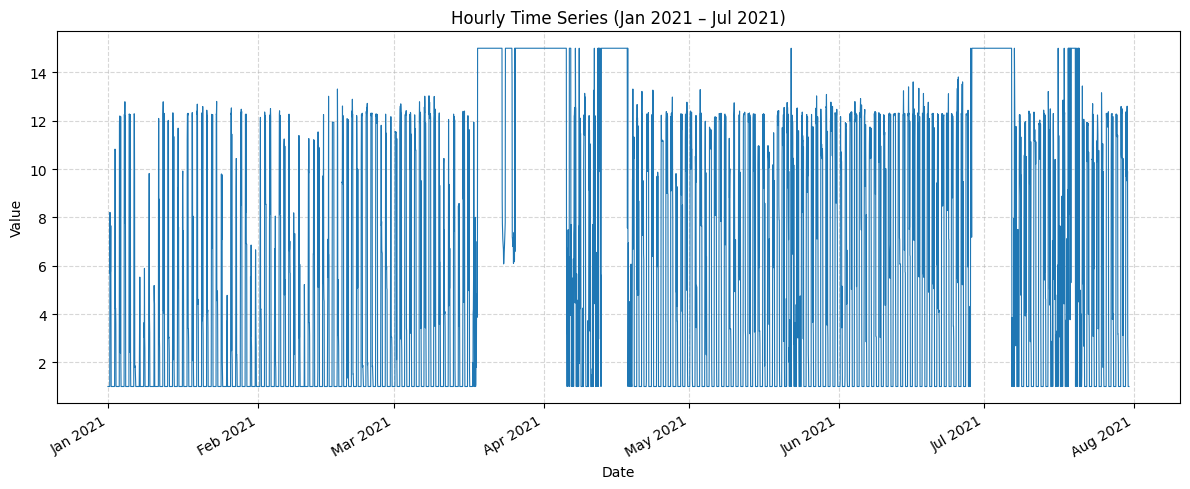

In [ ]:
time_index = pd.date_range(start='2021-01-01 00:00:00', periods=len(results), freq='h')

# 2. Create a Pandas DataFrame
df = pd.DataFrame({'Value': results}, index=time_index)

# 3. Plot the time series
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Value'], linewidth=0.8, color='#1f77b4')

# 4. Format the X-axis for clean month labels
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gcf().autofmt_xdate()  # Rotates date labels for readability

plt.title('Hourly Time Series (Jan 2021 – Jul 2021)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### Refactor EnKF and MPC Controller

In [ ]:
t_windows = 15
horizon_hours = 12
step_hours = 1
n_samples = 500
water_threshold = 30
R = 0.25
Q = 3
seed=42

sensor = SensorEmulator(threat_data_raw, max_frequency=360, horizon_hours=horizon_hours, step_hours=step_hours,
                        t_windows=t_windows, R=R, seed=seed,)

initial_forecast = sensor.generate_initial_forecast(initial_frequency=5, n_samples=n_samples)

enkf = EnsembleKalmanFilter(n_ens=n_samples, R=R, Q=Q, alpha=0.3, sigma=3, bias=(0, 0), seed=seed,)
enkf.initialize_ensemble(initial_forecast, init_state_length=61)
# print(f"Initial ensemble X_a shape: {enkf.X_a.shape}")
prev_num_obs = 0
applied_fs = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in range(t_windows - 1):
    afs = applied_fs[k]
    print(f"\n================ Window {k} ================")
    print(f"Applied Frequency: {afs}")
    # (Noisy Measurements for the 1 hour window, Timestamps for the 12 hour Window)
    obs_synthetic_win, horizon_timestamps = sensor.get_window_data(current_window=k,
                                                                   current_frequency=afs)
    num_obs = len(obs_synthetic_win)
    print(f"Collected {num_obs} noisy observations.")

    if k > 0:
        enkf.prepare_window_state(prev_num_obs=prev_num_obs,
            horizon_timestamps=horizon_timestamps,
            obs_df_clean=sensor.master_obs_df_dedup,
            window_id=k)
        print(f"Post-handover ensemble X_a shape: {enkf.X_a.shape}")

    # Assimilate window observations
    y_noisy = obs_synthetic_win["Instantaneous Stream Level (ft)"]
    print(f"Pre-assimilation state mean: {np.mean(enkf.X_a):.3f}, std: {np.std(enkf.X_a):.3f}")
    enkf.assimilate_window(y_obs_window=y_noisy, sampling_frequency=afs, window_id=k, 
                           timestamps_window=obs_synthetic_win.index.to_series(),)
    print(f"Post-assimilation state mean: {np.mean(enkf.X_a):.3f}, std: {np.std(enkf.X_a):.3f}")

#     # Calculate event probability
#     # prob = enkf.get_horizon_event_probabilities(threshold=water_threshold)
#     # print(f"Event Probability (Level > {water_threshold} ft): {prob}")
    prev_num_obs = num_obs - 1